<a href="https://www.kaggle.com/code/lalit7881/global-e-commerce-customer-analytics-2024-eda?scriptVersionId=324649343" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anasriaz/global-e-commerce-customer-analytics-2024/ecommerce_customer_analytics.csv
/kaggle/input/datasets/anasriaz/global-e-commerce-customer-analytics-2024/data_dictionary.csv
/kaggle/input/datasets/anasriaz/global-e-commerce-customer-analytics-2024/dataset-metadata.json


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/anasriaz/global-e-commerce-customer-analytics-2024/ecommerce_customer_analytics.csv")

In [3]:
df.head()

,customer_id,age,gender,country,region,income_bracket,signup_date,last_purchase_date,customer_lifetime_days,days_since_last_purchase,...,device_type,loyalty_tier,discount_usage_rate,return_rate,newsletter_subscribed,referral_source,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
0,CUST-00001,35,Male,United States,North America,"$75,000–$99,999",2022-10-17,2024-11-13,759,48,...,Desktop,Platinum,0.229,0.084,False,Social Media,10.2,6.4,4,0
1,CUST-00002,58,Male,Germany,Europe,"$25,000–$49,999",2020-12-05,2024-04-24,1237,251,...,Mobile,Gold,0.349,0.019,True,Social Media,1.0,6.9,5,0
2,CUST-00003,43,Female,Australia,Asia-Pacific,"$75,000–$99,999",2019-05-27,2022-10-25,1248,798,...,Desktop,Platinum,0.186,0.117,True,Paid Ad,7.4,1.1,3,1
3,CUST-00004,54,Male,United Kingdom,Europe,"$25,000–$49,999",2022-02-23,2023-08-15,539,504,...,Mobile,Gold,0.048,0.130,True,Referral,14.4,5.8,5,1
4,CUST-00005,30,Male,Brazil,Latin America,"Under $25,000",2021-06-09,2022-04-28,324,978,...,Mobile,Bronze,0.056,0.085,True,Email Campaign,5.7,4.3,5,1


In [4]:
df.tail()

,customer_id,age,gender,country,region,income_bracket,signup_date,last_purchase_date,customer_lifetime_days,days_since_last_purchase,...,device_type,loyalty_tier,discount_usage_rate,return_rate,newsletter_subscribed,referral_source,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
1195,CUST-01196,39,Female,United States,North America,"$25,000–$49,999",2022-11-10,2023-01-02,54,729,...,Mobile,Bronze,0.310,0.408,True,Organic Search,7.8,1.8,2,1
1196,CUST-01197,18,Female,France,Europe,"$75,000–$99,999",2023-03-22,2023-11-16,240,411,...,Mobile,Gold,0.362,0.119,True,Paid Ad,10.3,8.5,3,1
1197,CUST-01198,45,Male,United States,North America,"$75,000–$99,999",2023-01-25,2024-04-05,437,270,...,Desktop,Gold,0.269,0.129,True,Paid Ad,2.5,2.7,4,0
1198,CUST-01199,18,Male,Japan,Asia-Pacific,"$75,000–$99,999",2021-04-29,2022-01-10,257,1086,...,Desktop,Gold,0.372,0.048,False,Organic Search,17.3,7.7,5,1
1199,CUST-01200,39,Male,United Kingdom,Europe,"$50,000–$74,999",2020-03-02,2023-11-12,1351,415,...,Mobile,Platinum,0.231,0.532,True,Email Campaign,1.0,5.6,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1200 non-null   int64  
 2   gender                    1200 non-null   object 
 3   country                   1200 non-null   object 
 4   region                    1200 non-null   object 
 5   income_bracket            1200 non-null   object 
 6   signup_date               1200 non-null   object 
 7   last_purchase_date        1200 non-null   object 
 8   customer_lifetime_days    1200 non-null   int64  
 9   days_since_last_purchase  1200 non-null   int64  
 10  total_orders              1200 non-null   int64  
 11  total_spent_usd           1200 non-null   float64
 12  avg_order_value_usd       1200 non-null   float64
 13  preferred_category        1200 non-null   object 
 14  preferre

In [6]:
df.describe()

,age,customer_lifetime_days,days_since_last_purchase,total_orders,total_spent_usd,avg_order_value_usd,discount_usage_rate,return_rate,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000
mean,36.791667,640.200833,638.739167,54.095000,5300.141033,80.912325,0.257473,0.138565,8.040333,5.41300,3.378333,0.673333
std,11.766774,457.392649,485.209951,58.386415,9462.359979,48.874175,0.148585,0.107034,3.833465,2.37341,1.272090,0.469190
min,18.000000,1.000000,0.000000,1.000000,7.290000,4.990000,0.002000,0.001000,1.000000,1.00000,1.000000,0.000000
25%,28.000000,265.000000,249.000000,14.000000,795.420000,48.820000,0.142000,0.058000,5.200000,3.70000,3.000000,0.000000
50%,36.000000,550.000000,521.500000,35.000000,2195.495000,71.390000,0.229000,0.111000,7.900000,5.40000,4.000000,1.000000
75%,45.000000,935.250000,925.500000,72.250000,5827.155000,97.930000,0.350250,0.194000,10.700000,7.00000,4.000000,1.000000
max,75.000000,1995.000000,2152.000000,350.000000,107142.560000,363.730000,0.738000,0.641000,20.000000,12.90000,5.000000,1.000000


In [7]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
country                     0
region                      0
income_bracket              0
signup_date                 0
last_purchase_date          0
customer_lifetime_days      0
days_since_last_purchase    0
total_orders                0
total_spent_usd             0
avg_order_value_usd         0
preferred_category          0
preferred_payment_method    0
device_type                 0
loyalty_tier                0
discount_usage_rate         0
return_rate                 0
newsletter_subscribed       0
referral_source             0
avg_session_duration_min    0
avg_pages_per_session       0
satisfaction_score          0
churn                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

customer_id                  object
age                           int64
gender                       object
country                      object
region                       object
income_bracket               object
signup_date                  object
last_purchase_date           object
customer_lifetime_days        int64
days_since_last_purchase      int64
total_orders                  int64
total_spent_usd             float64
avg_order_value_usd         float64
preferred_category           object
preferred_payment_method     object
device_type                  object
loyalty_tier                 object
discount_usage_rate         float64
return_rate                 float64
newsletter_subscribed          bool
referral_source              object
avg_session_duration_min    float64
avg_pages_per_session       float64
satisfaction_score            int64
churn                         int64
dtype: object

In [10]:
df.shape

(1200, 25)

In [11]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'region', 'income_bracket',
       'signup_date', 'last_purchase_date', 'customer_lifetime_days',
       'days_since_last_purchase', 'total_orders', 'total_spent_usd',
       'avg_order_value_usd', 'preferred_category', 'preferred_payment_method',
       'device_type', 'loyalty_tier', 'discount_usage_rate', 'return_rate',
       'newsletter_subscribed', 'referral_source', 'avg_session_duration_min',
       'avg_pages_per_session', 'satisfaction_score', 'churn'],
      dtype='object')

In [12]:
df.nunique()

customer_id                 1200
age                           55
gender                         4
country                       15
region                         4
income_bracket                 6
signup_date                  860
last_purchase_date           843
customer_lifetime_days       813
days_since_last_purchase     843
total_orders                 202
total_spent_usd             1199
avg_order_value_usd         1146
preferred_category            10
preferred_payment_method       7
device_type                    3
loyalty_tier                   4
discount_usage_rate          486
return_rate                  353
newsletter_subscribed          2
referral_source                7
avg_session_duration_min     166
avg_pages_per_session        109
satisfaction_score             5
churn                          2
dtype: int64

In [13]:
print(df.columns.tolist())

['customer_id', 'age', 'gender', 'country', 'region', 'income_bracket', 'signup_date', 'last_purchase_date', 'customer_lifetime_days', 'days_since_last_purchase', 'total_orders', 'total_spent_usd', 'avg_order_value_usd', 'preferred_category', 'preferred_payment_method', 'device_type', 'loyalty_tier', 'discount_usage_rate', 'return_rate', 'newsletter_subscribed', 'referral_source', 'avg_session_duration_min', 'avg_pages_per_session', 'satisfaction_score', 'churn']


## EDA

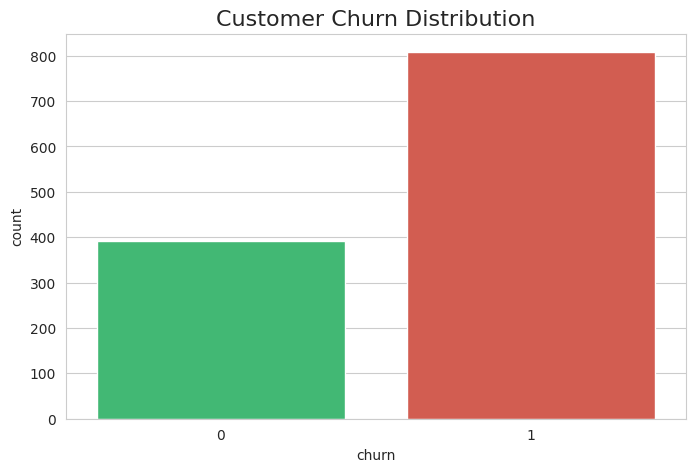

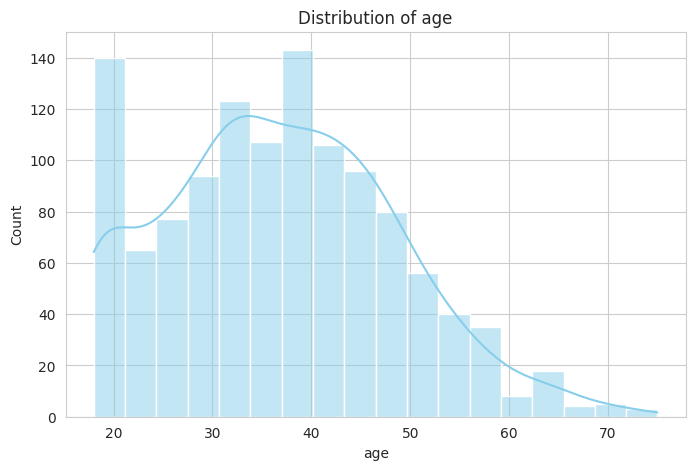

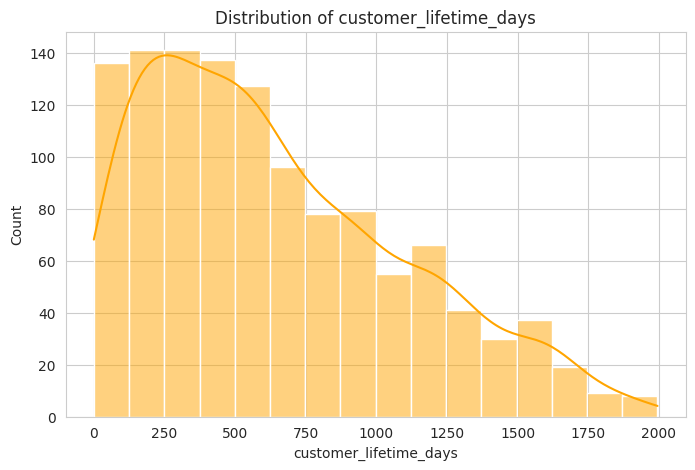

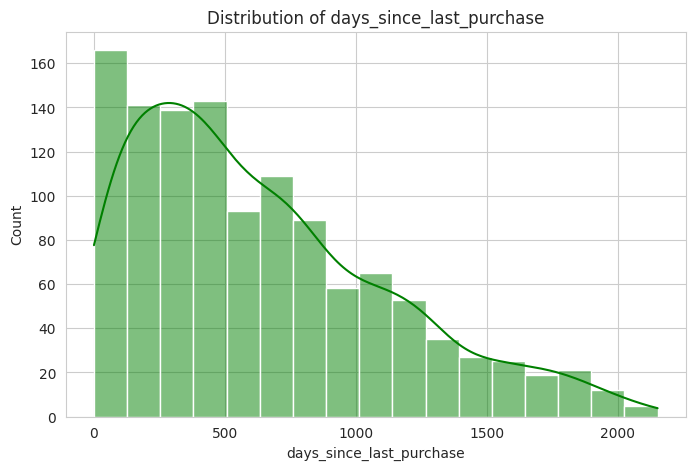

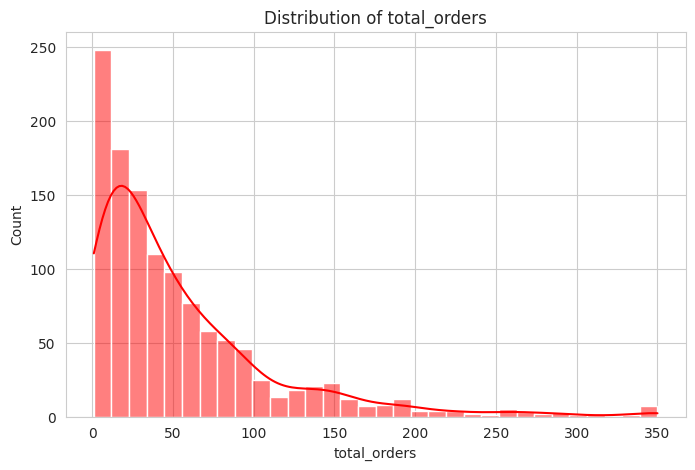

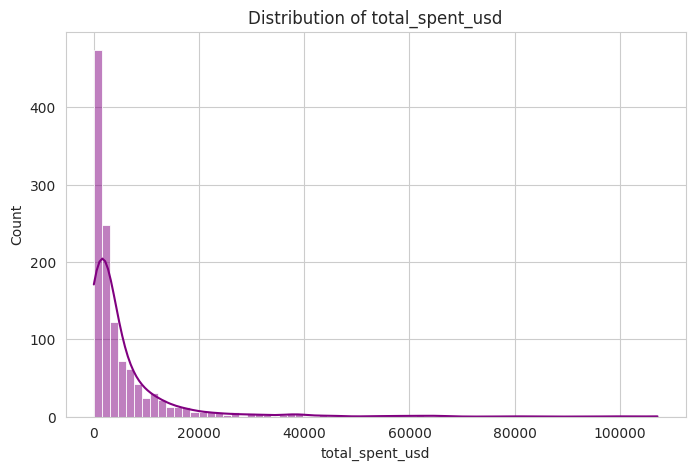

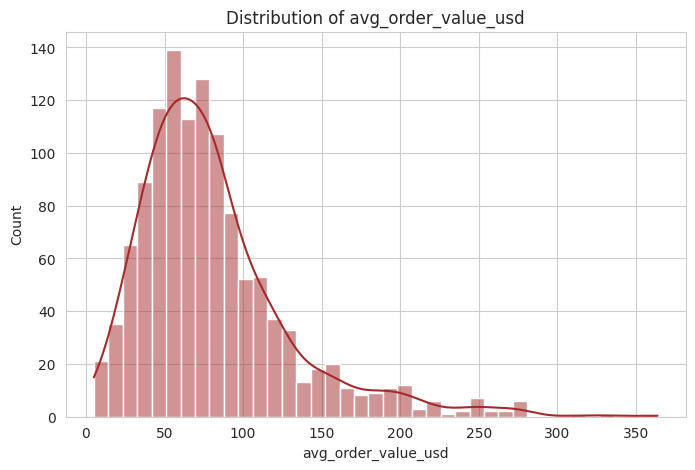

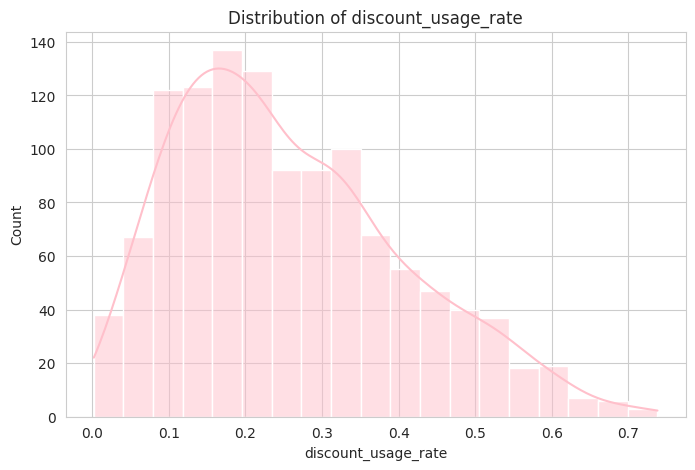

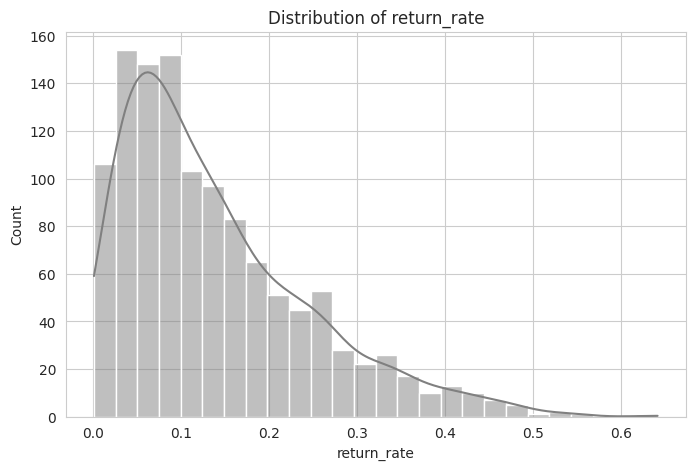

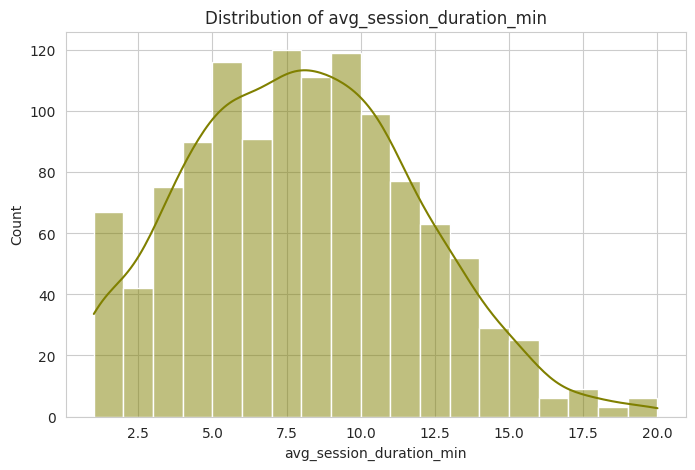

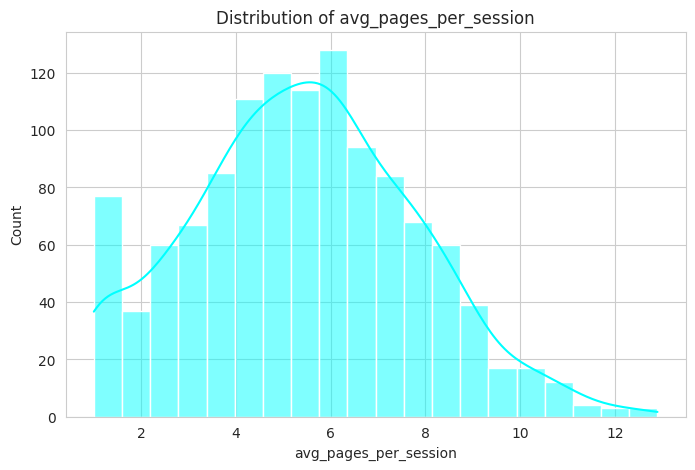

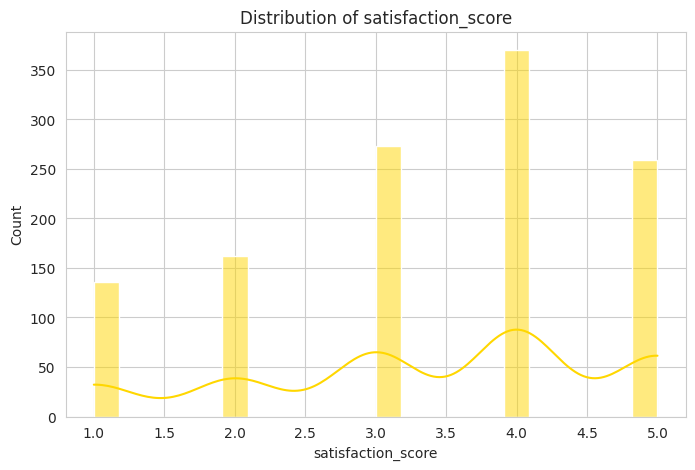

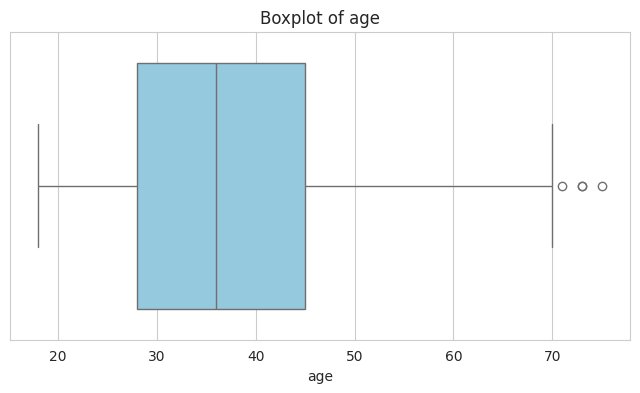

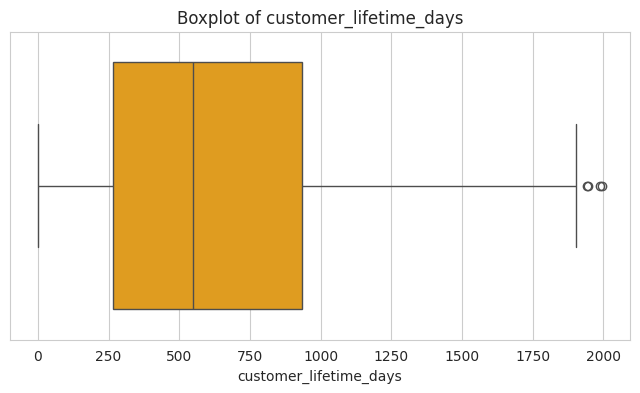

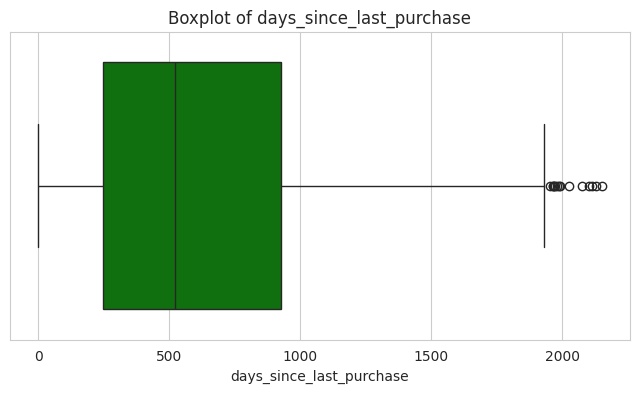

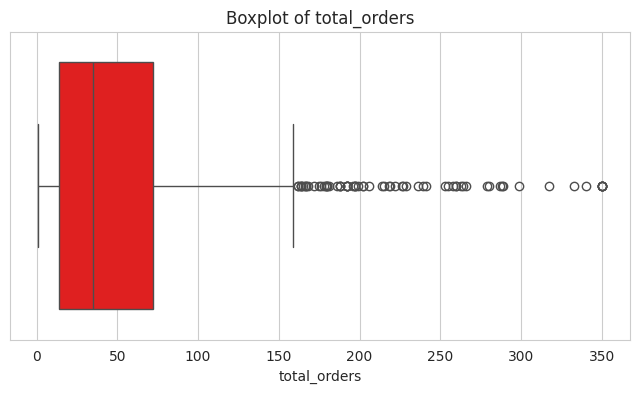

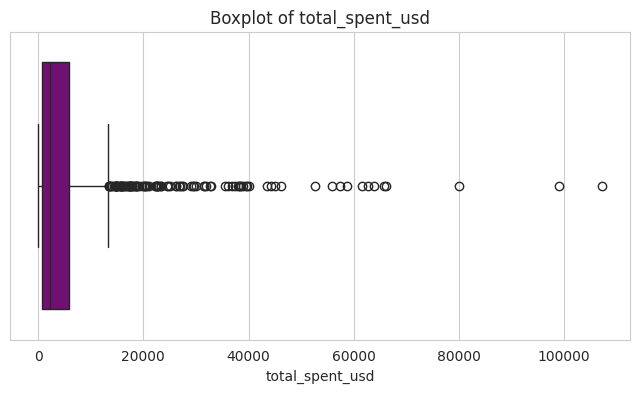

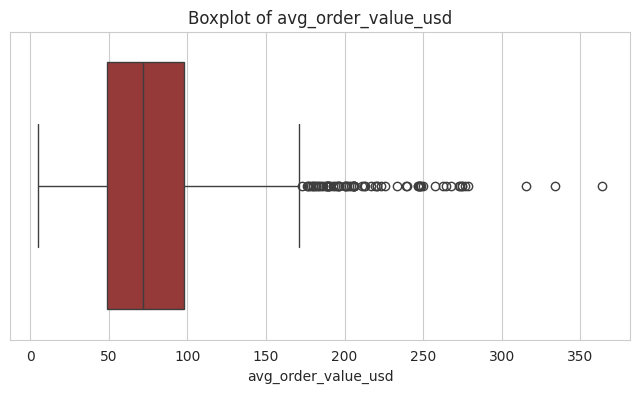

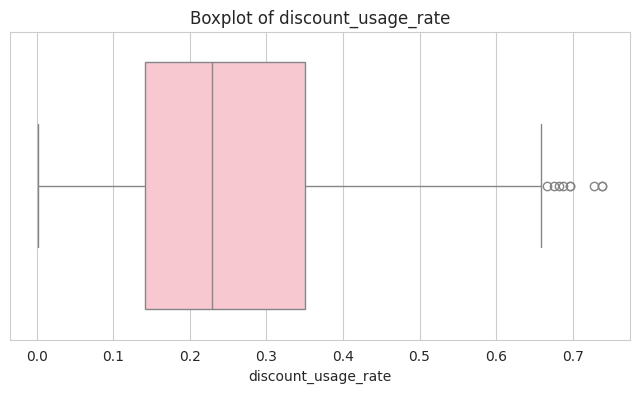

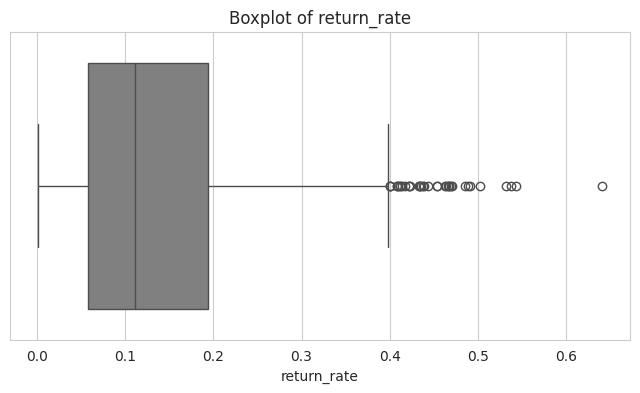

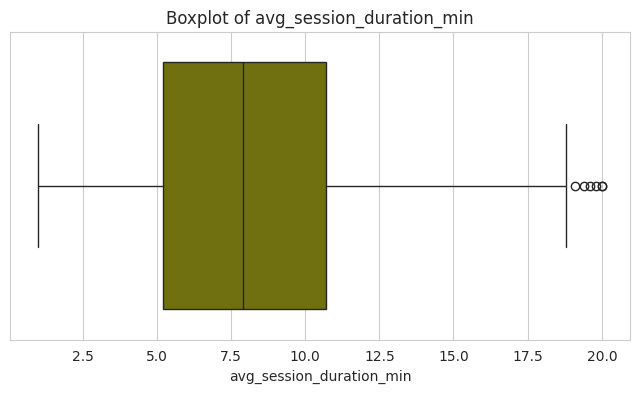

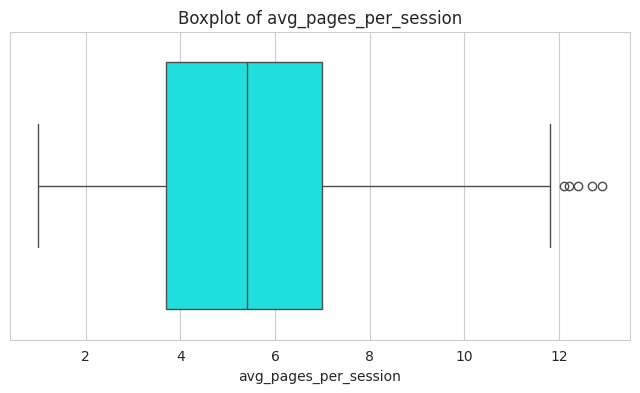

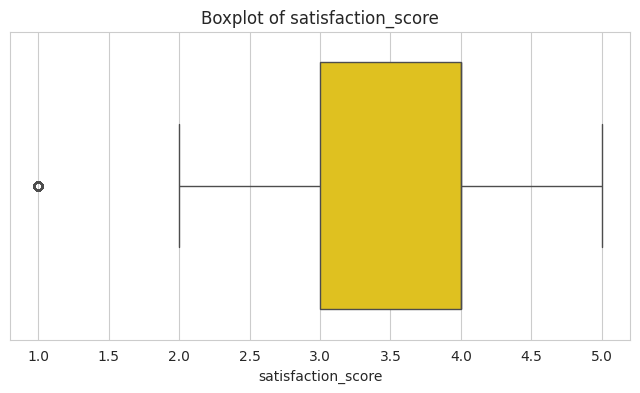

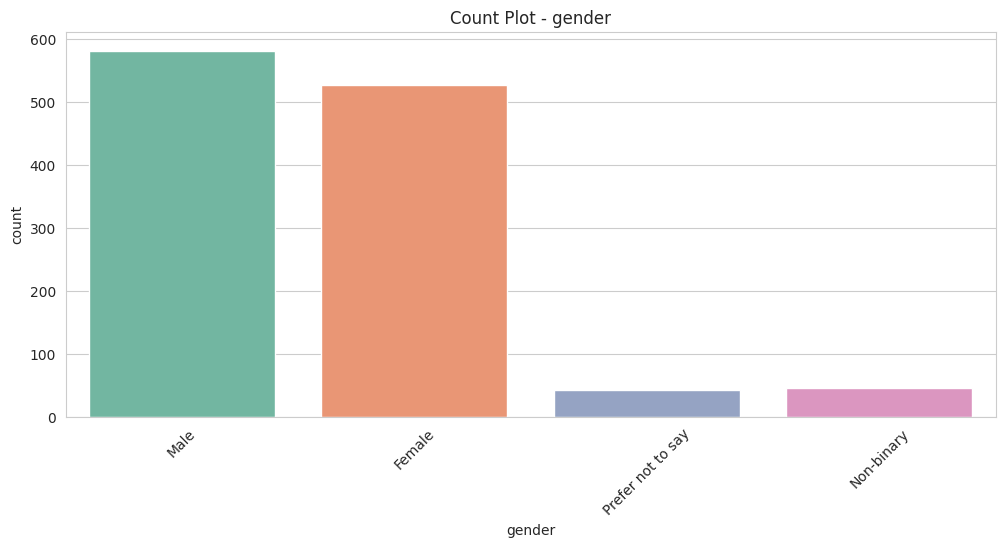

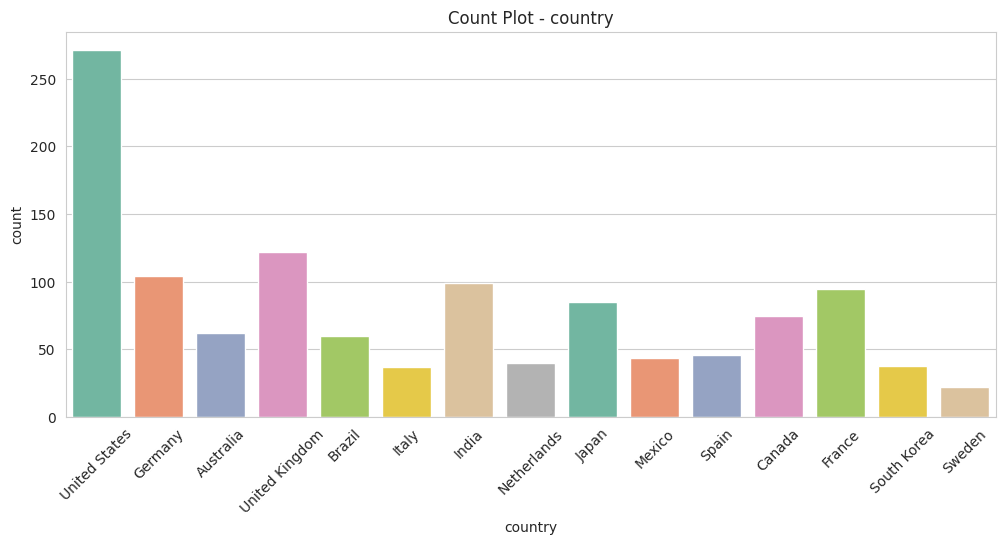

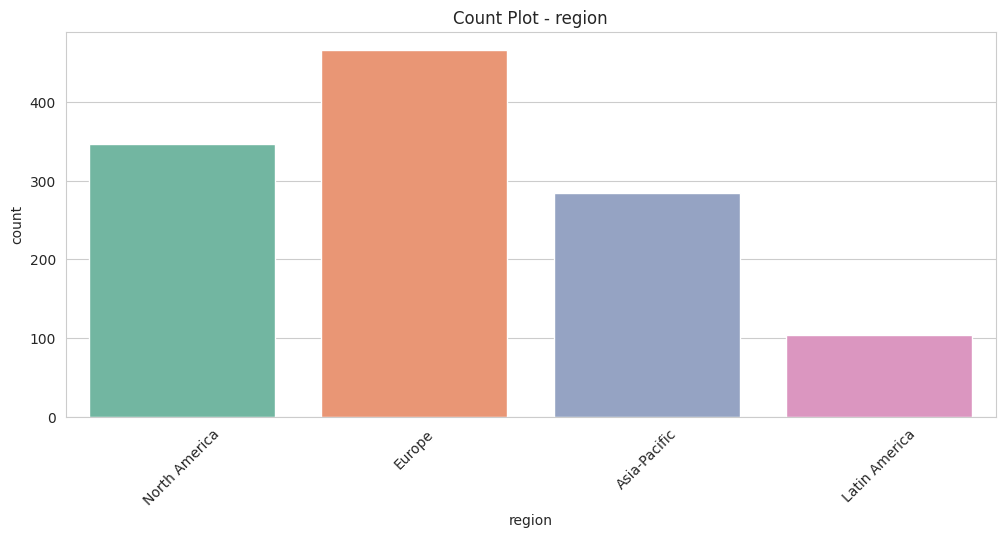

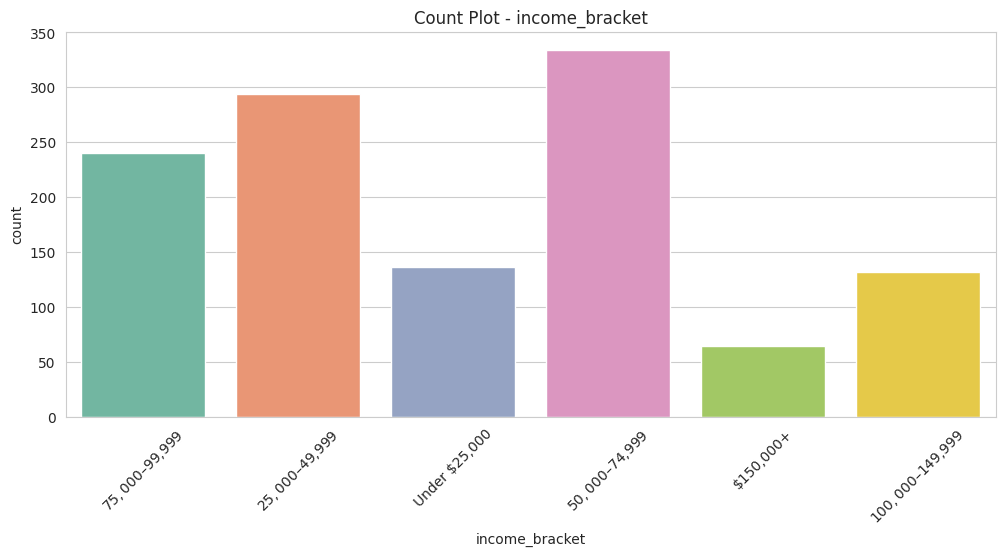

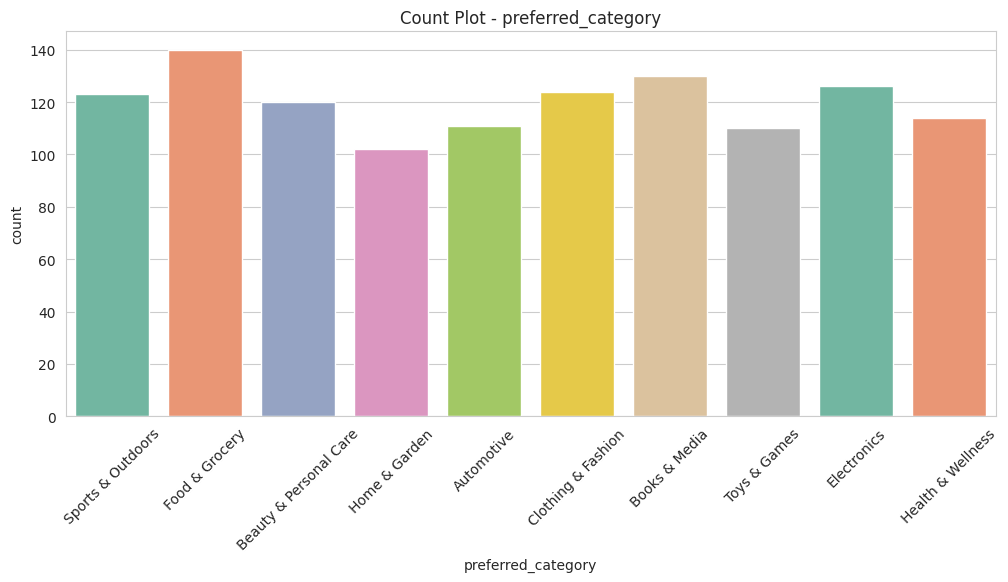

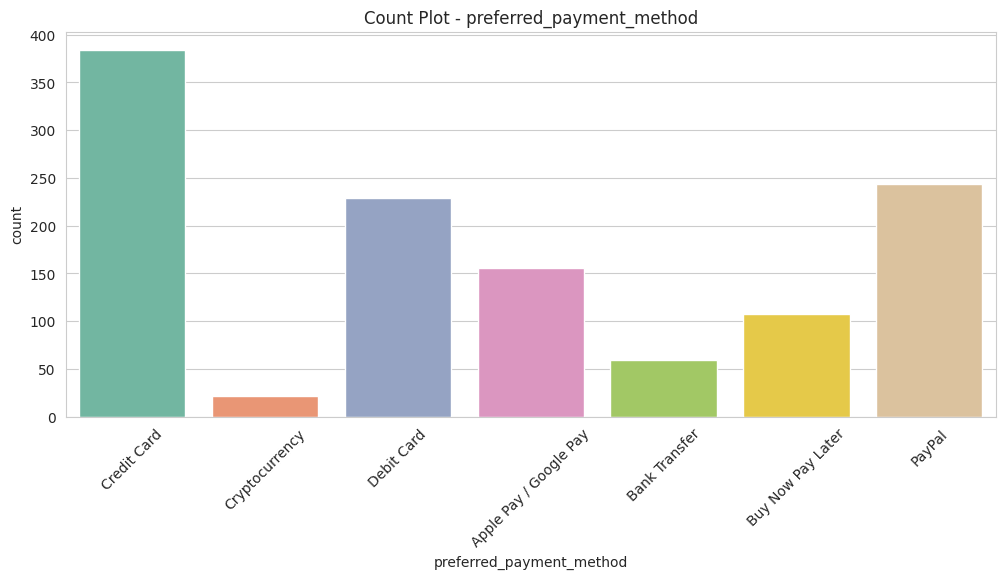

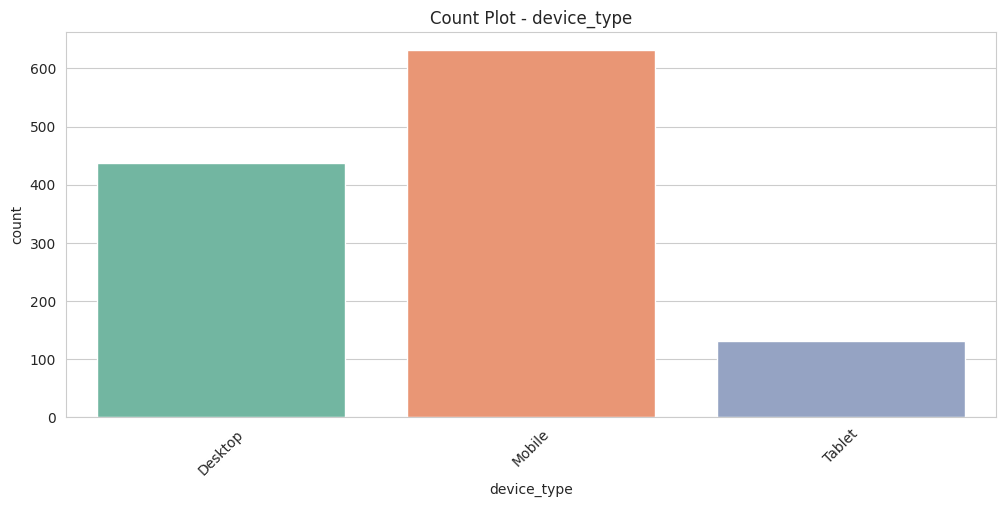

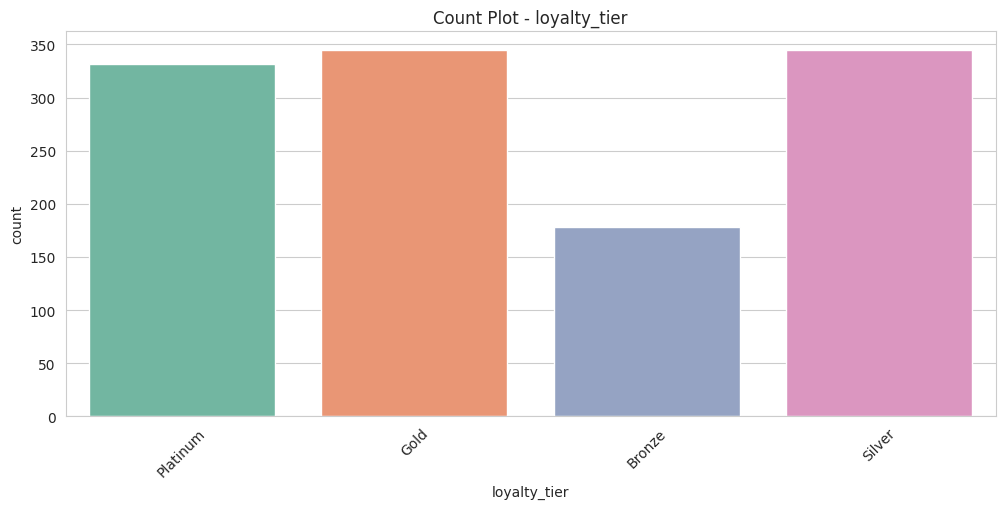

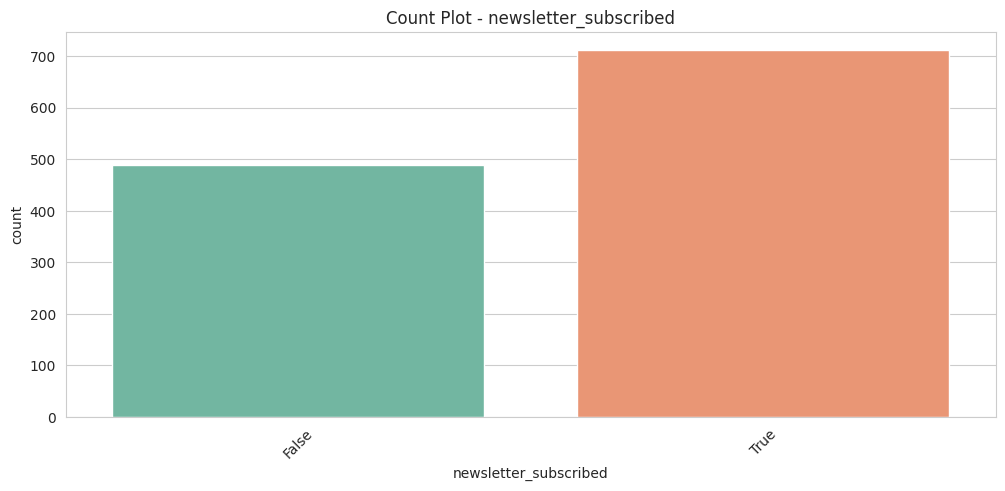

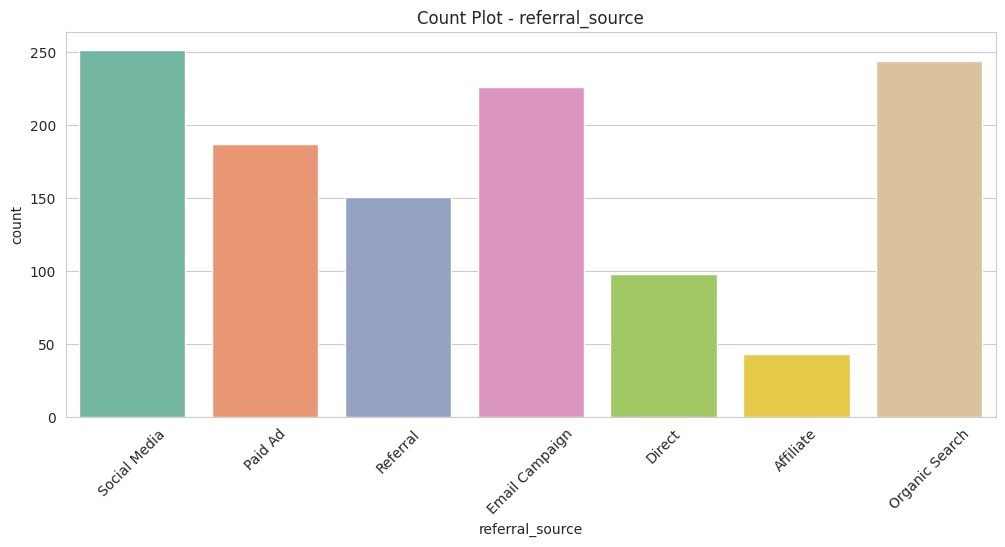

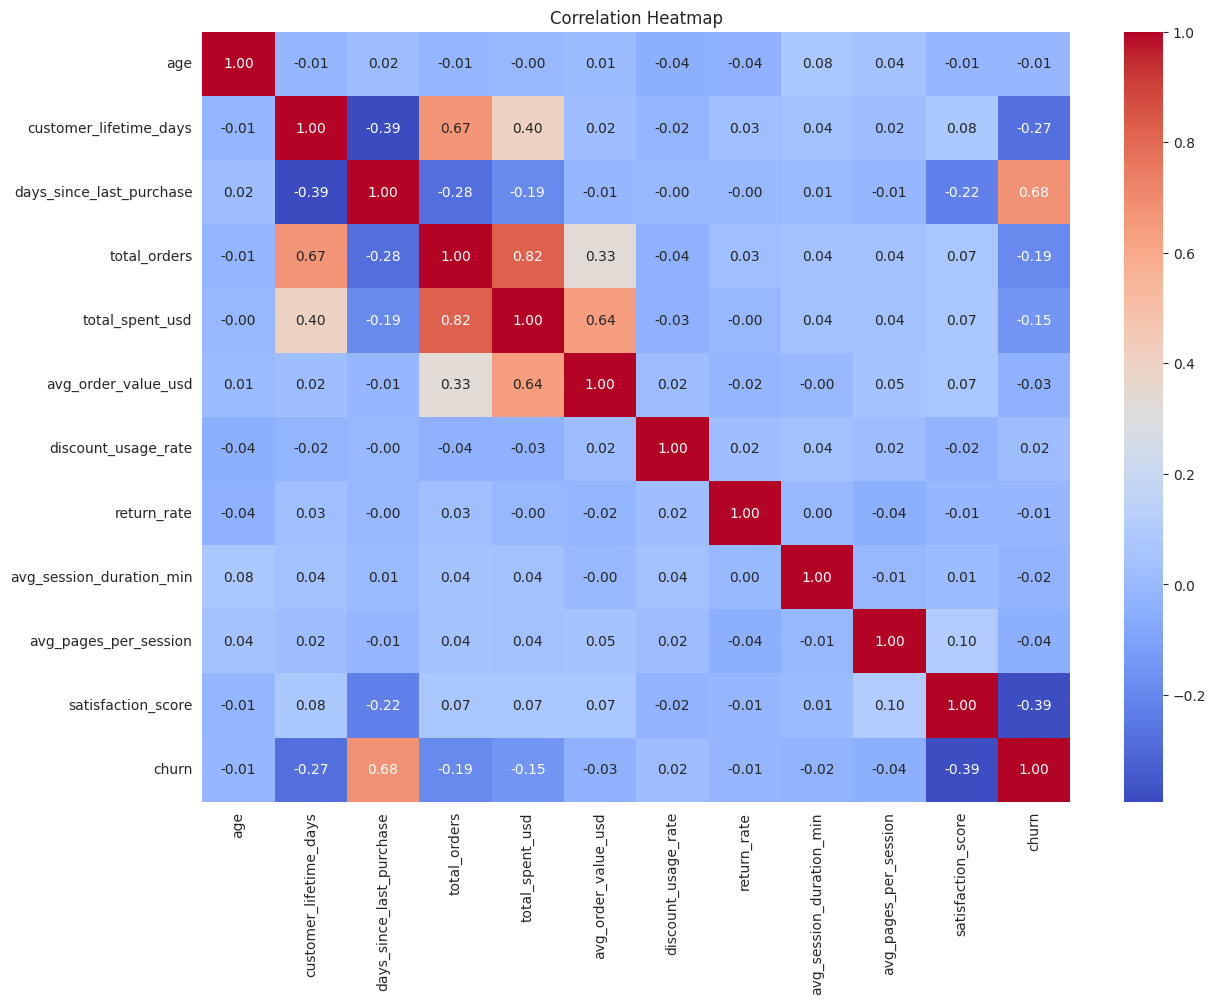

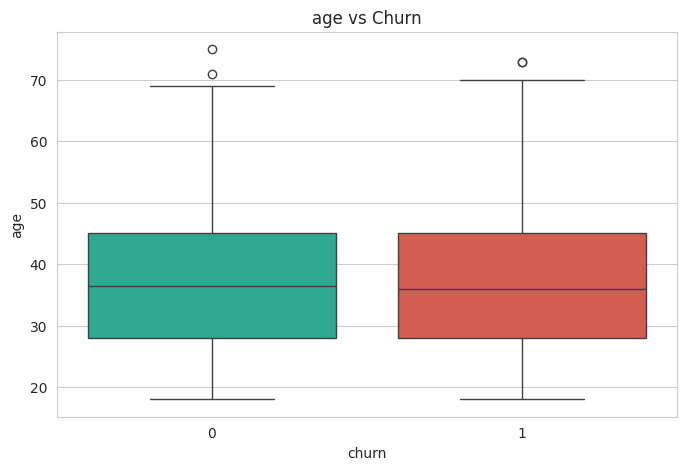

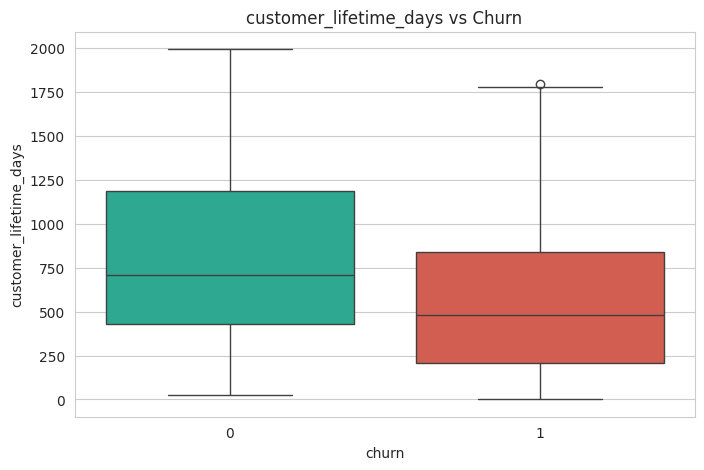

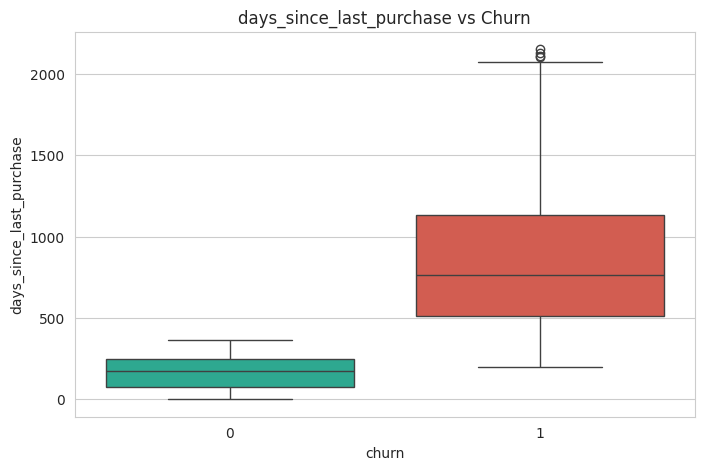

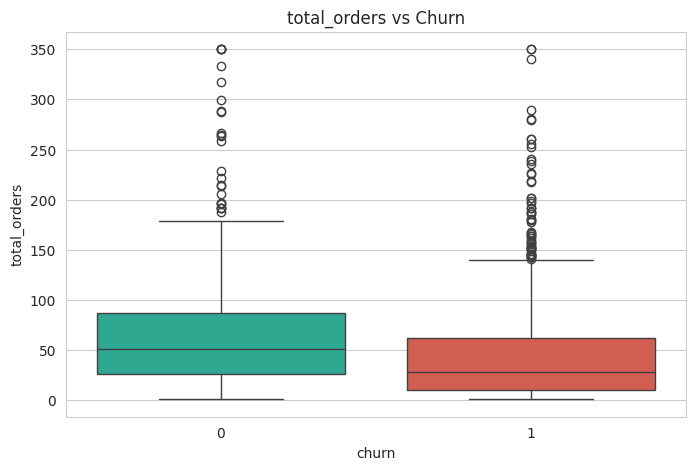

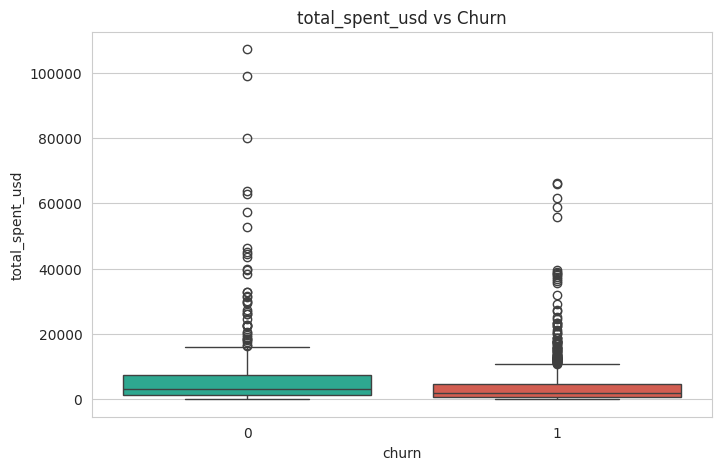

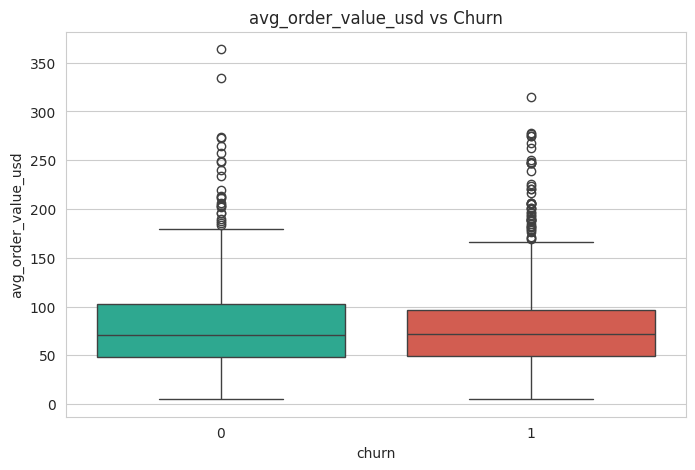

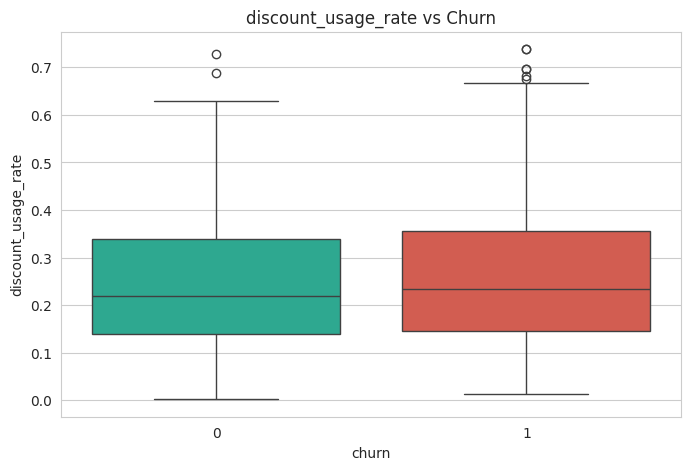

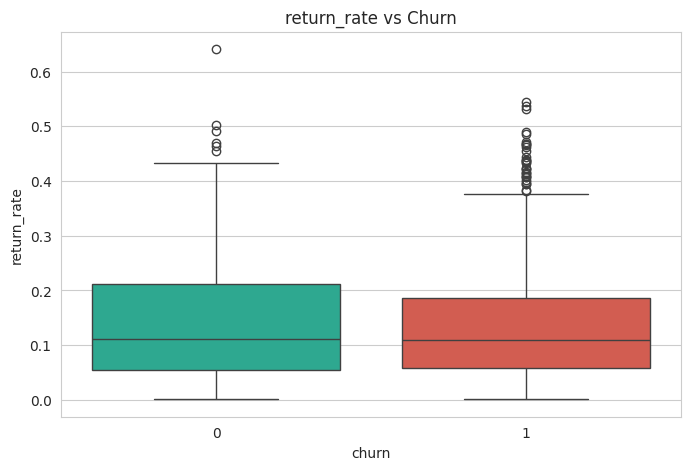

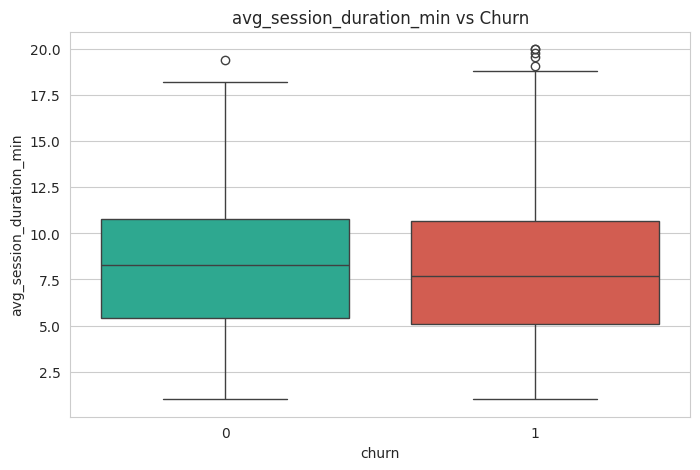

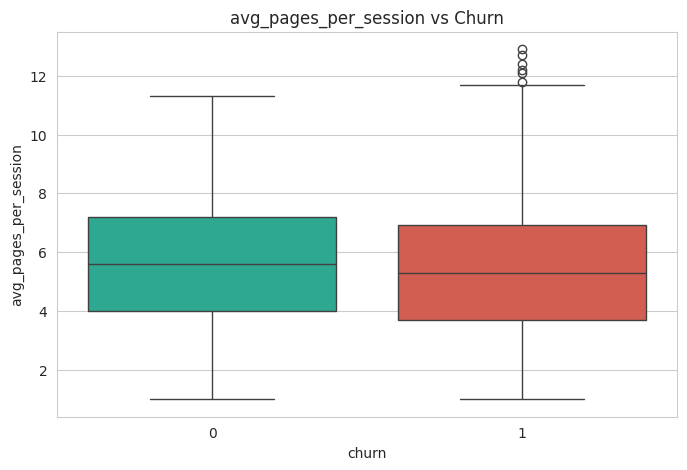

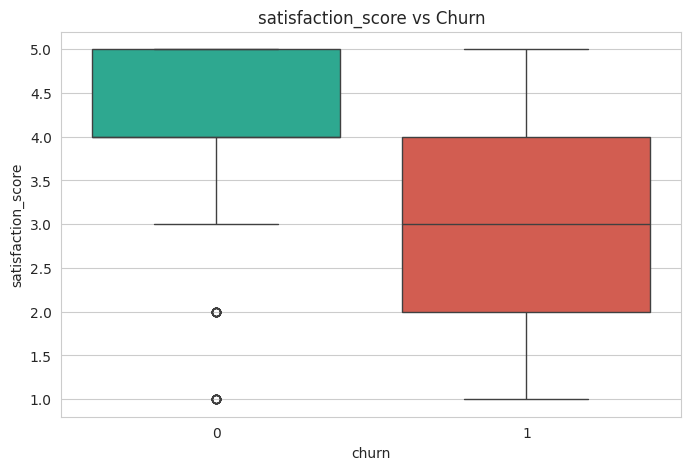

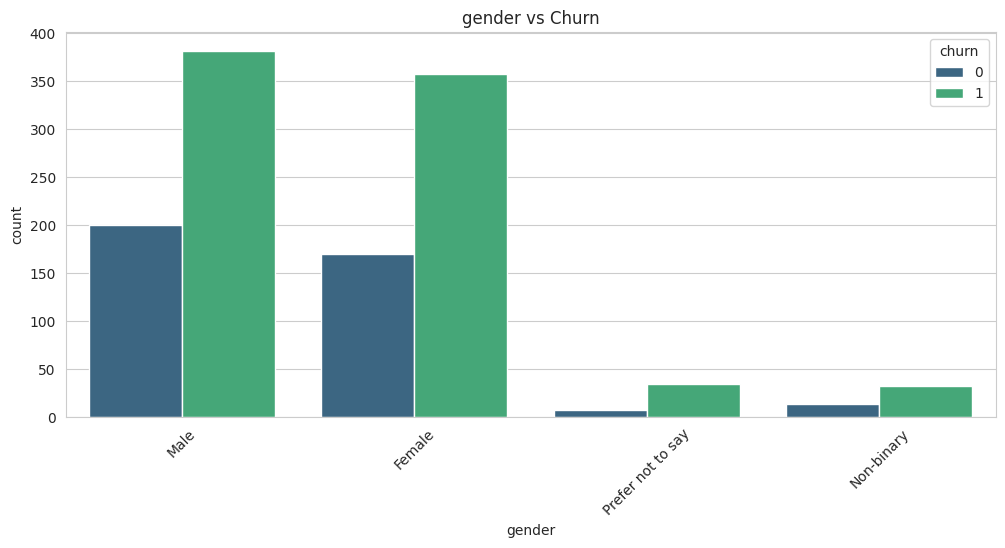

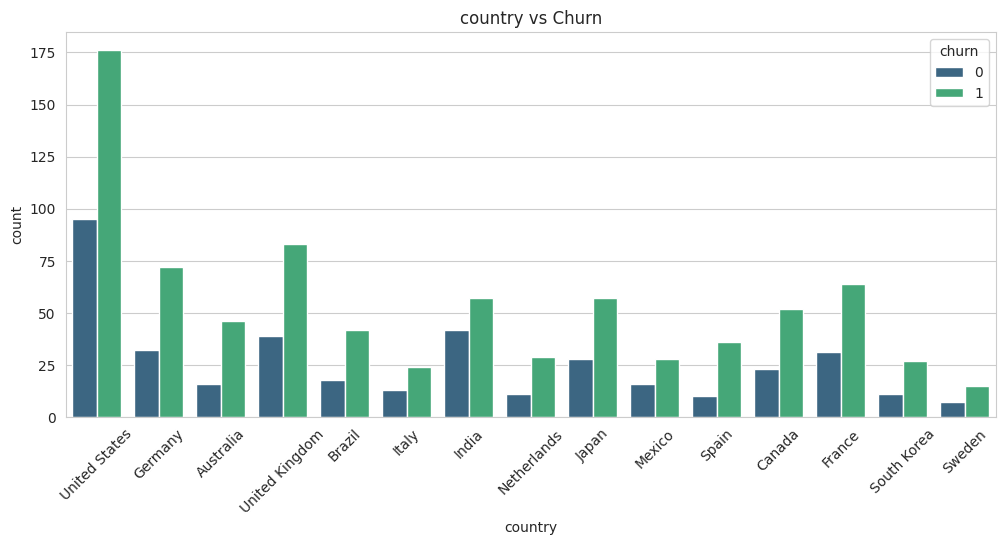

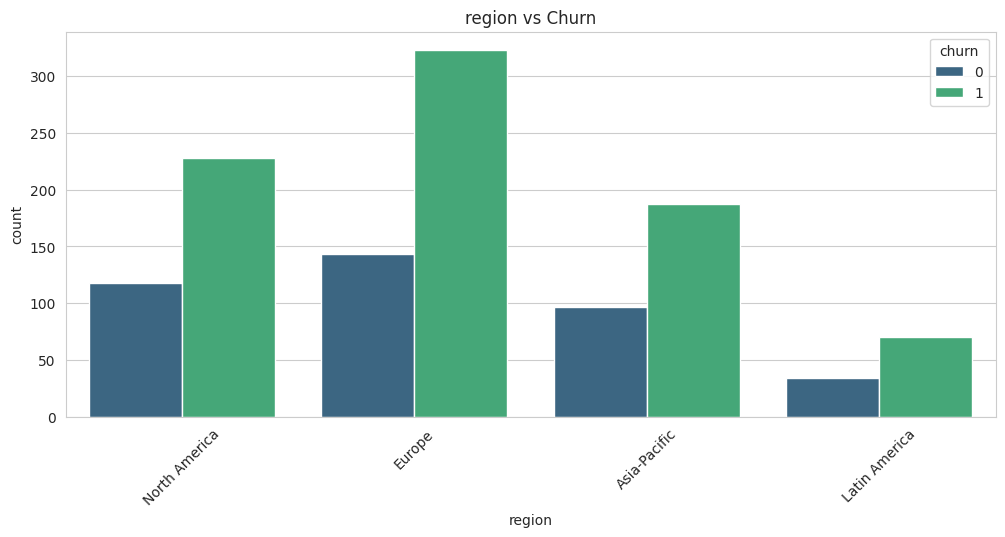

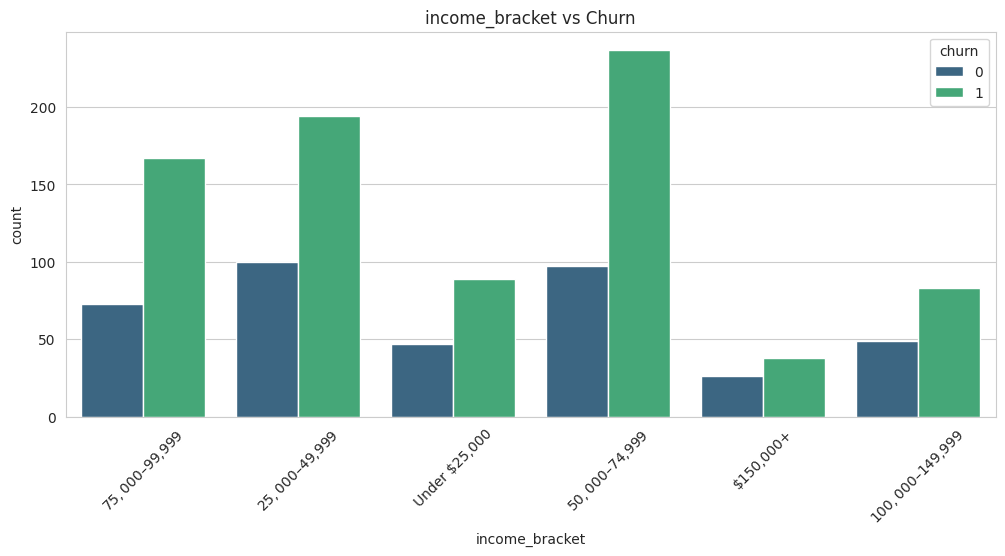

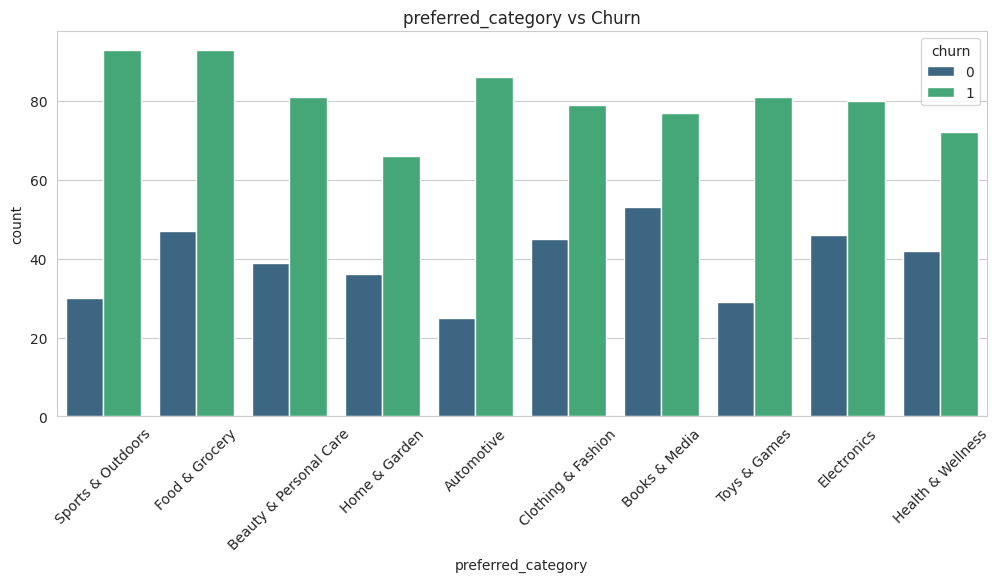

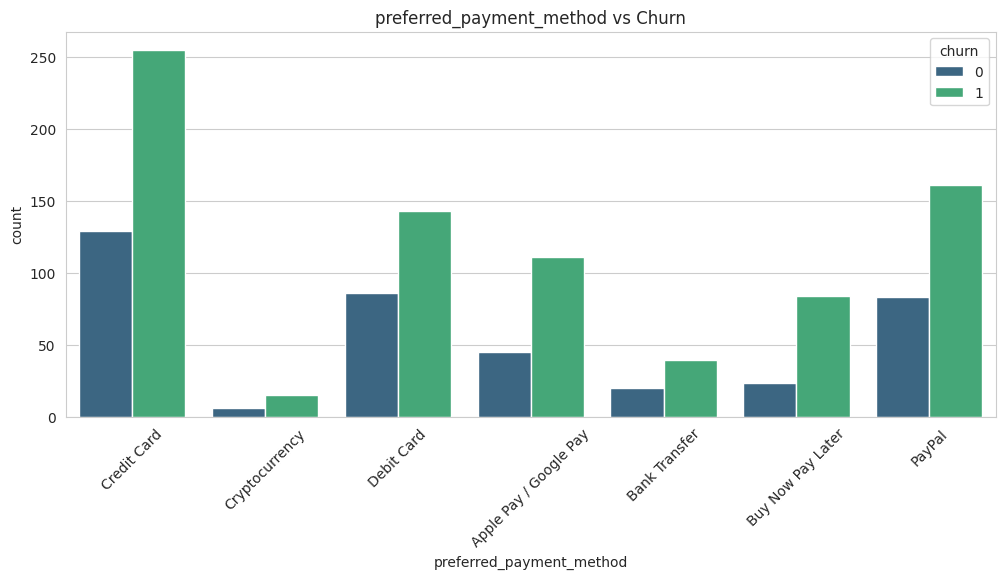

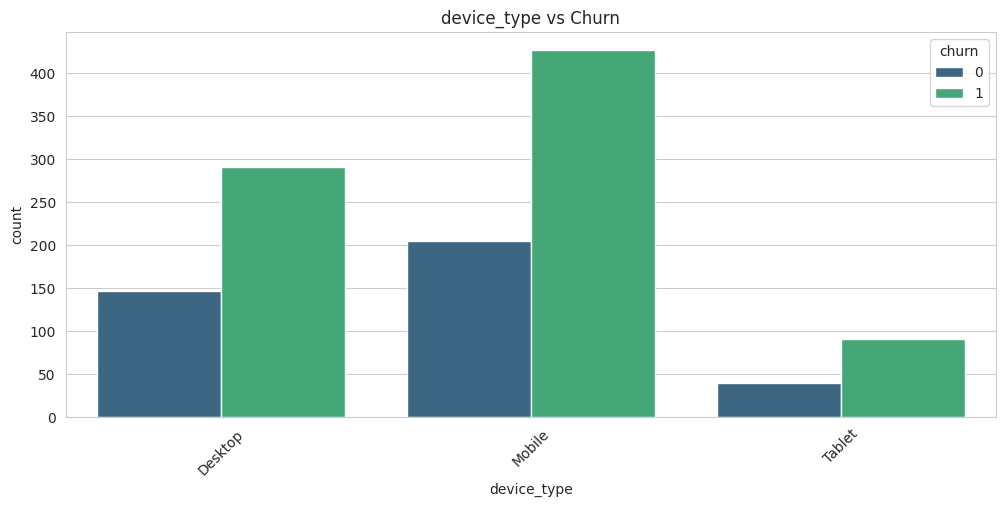

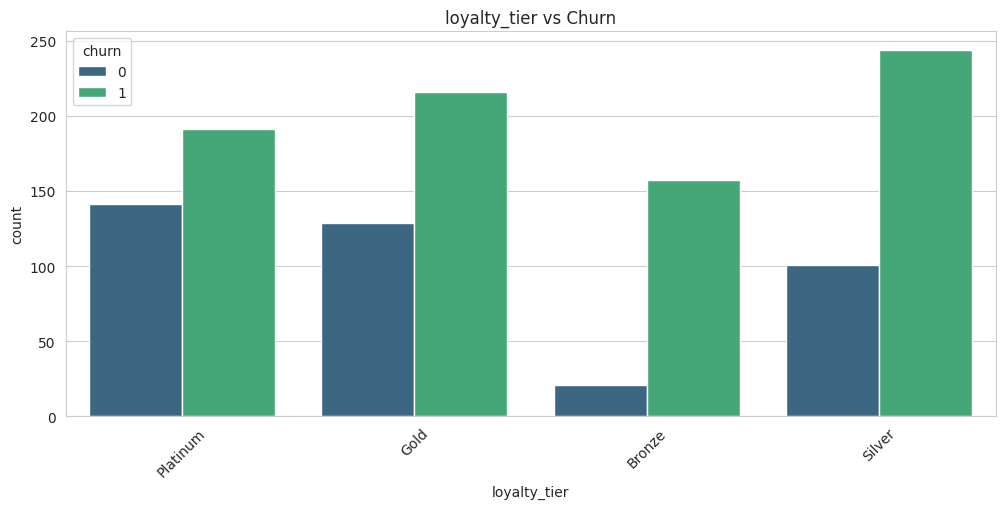

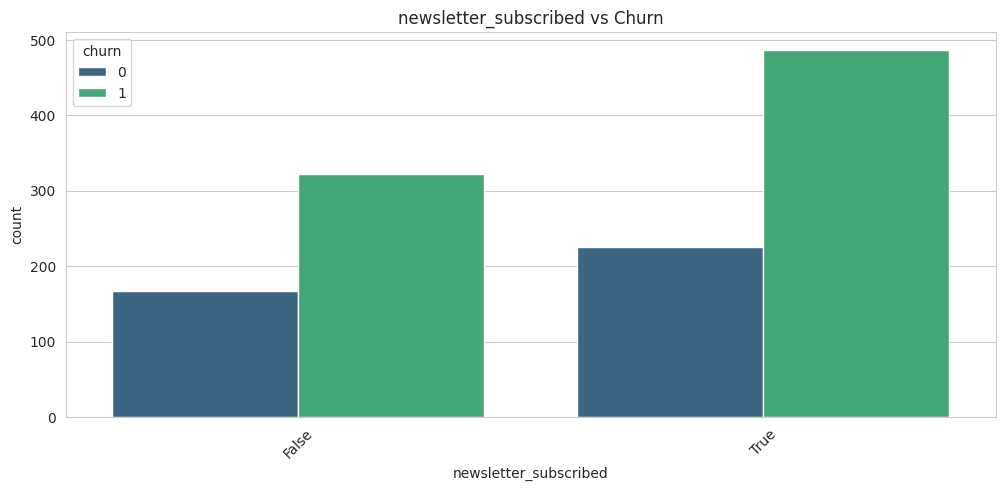

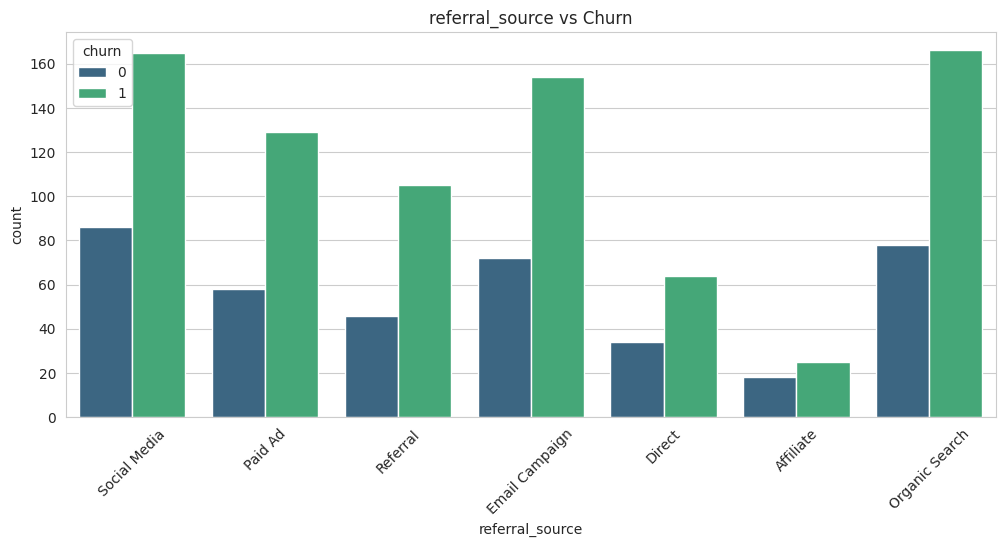

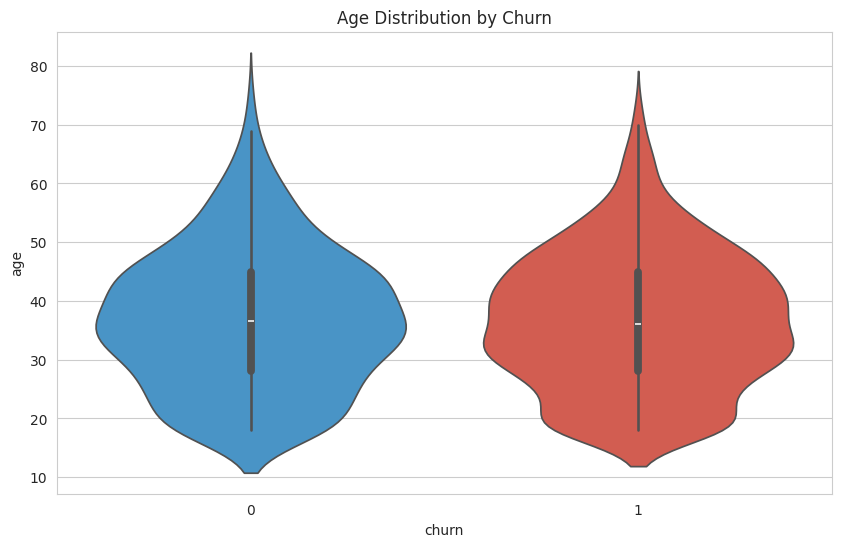

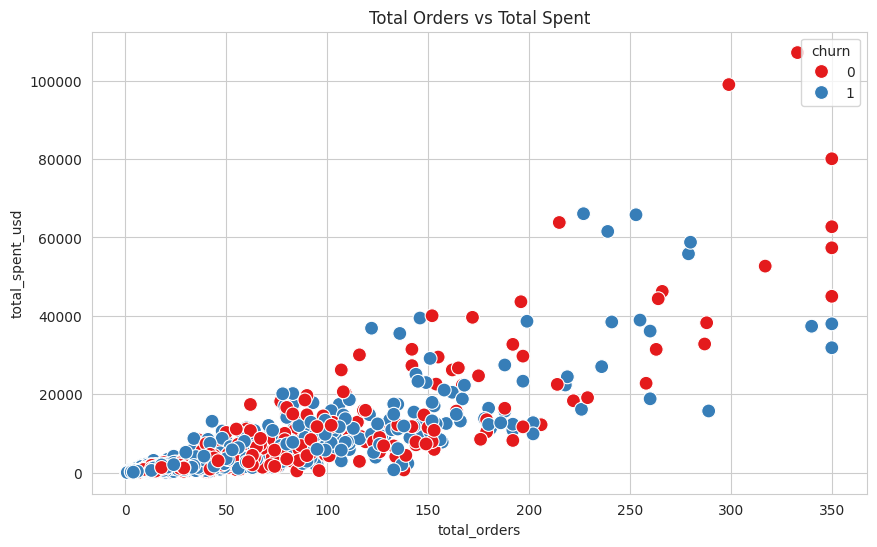

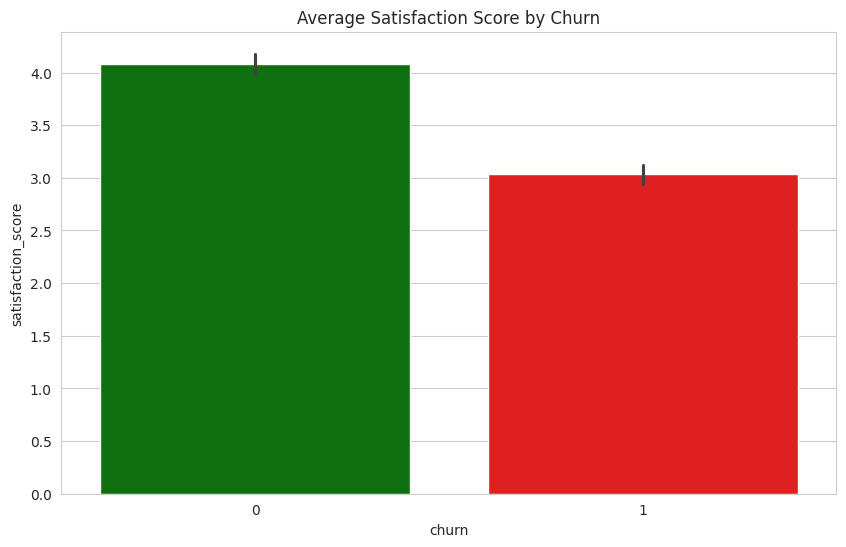

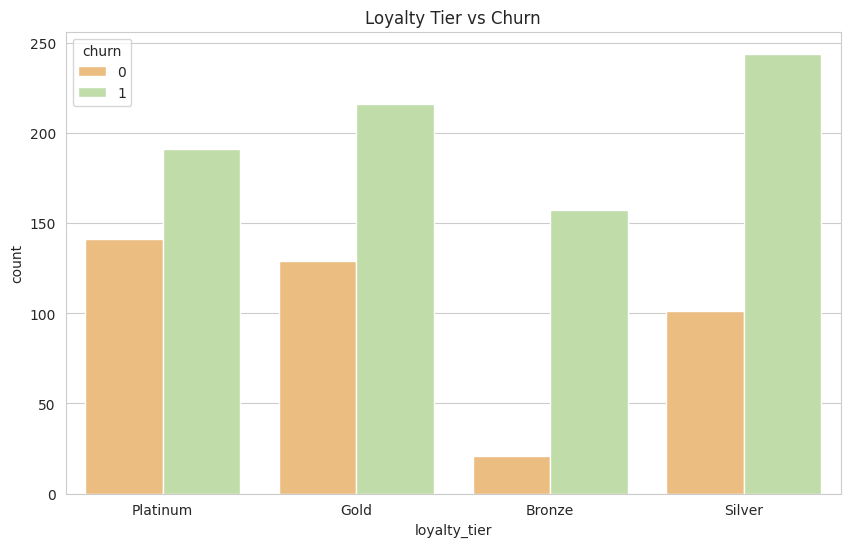

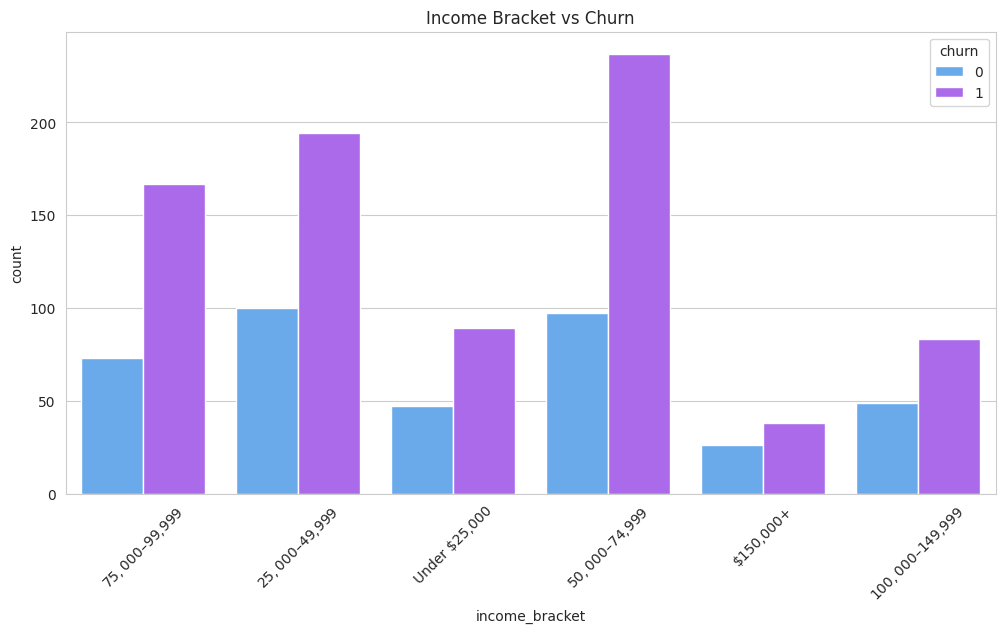

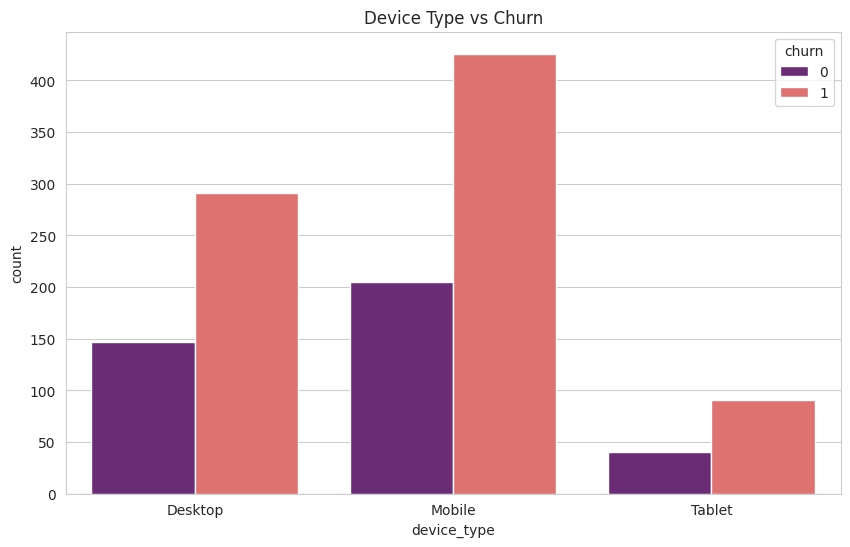

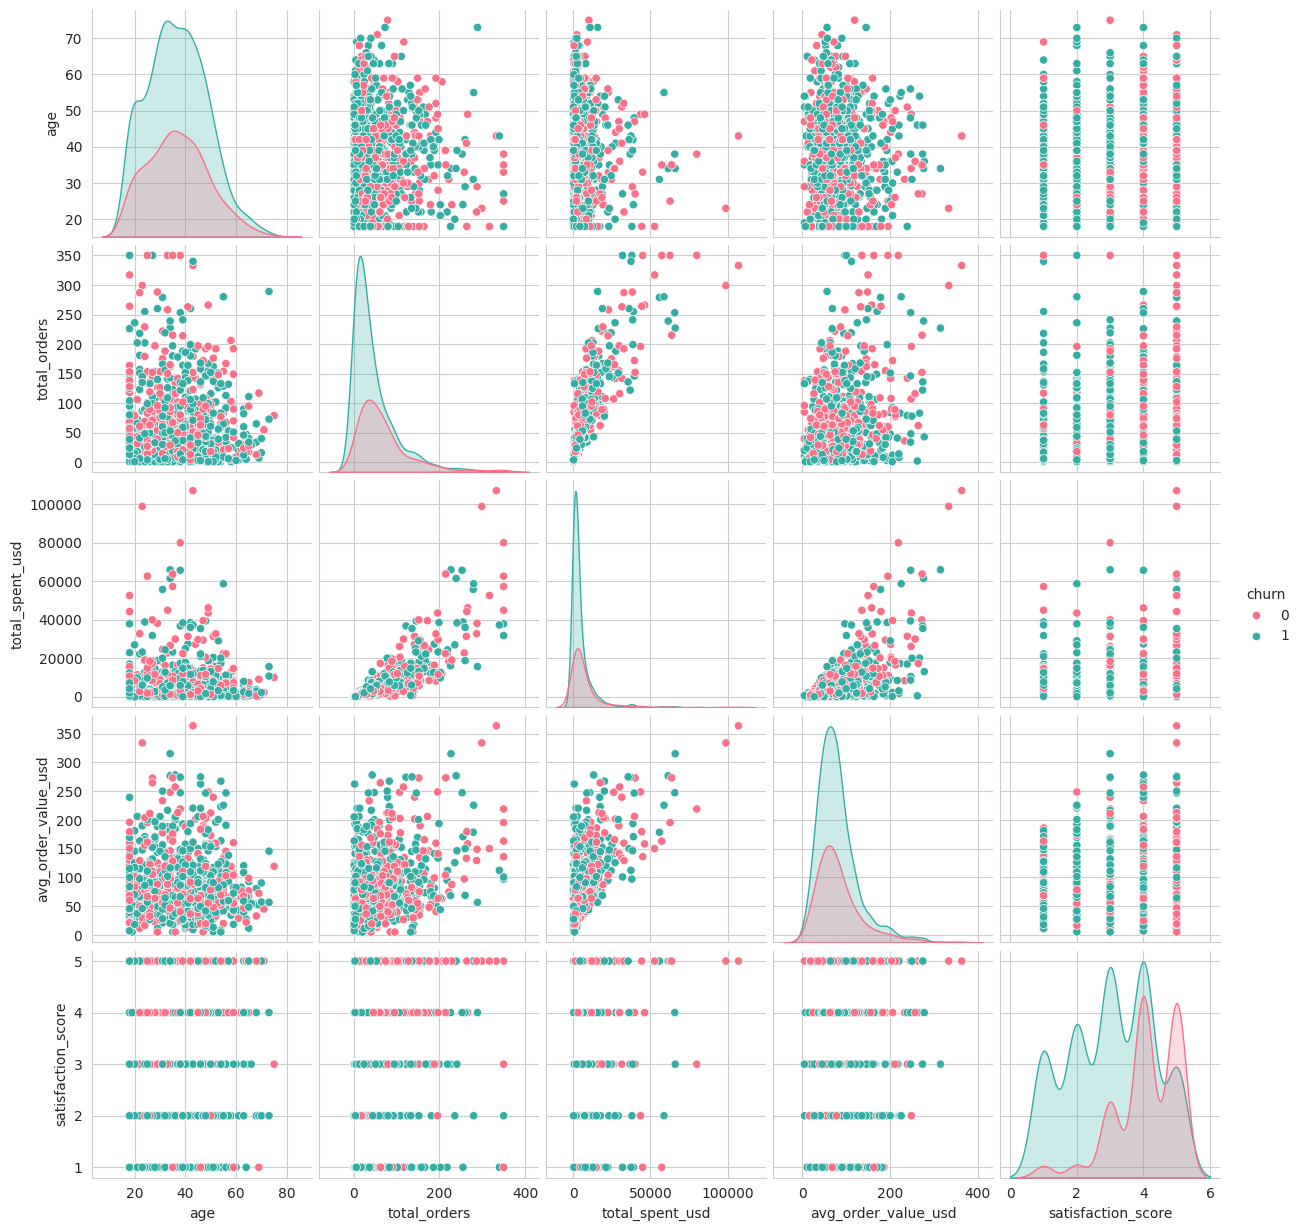

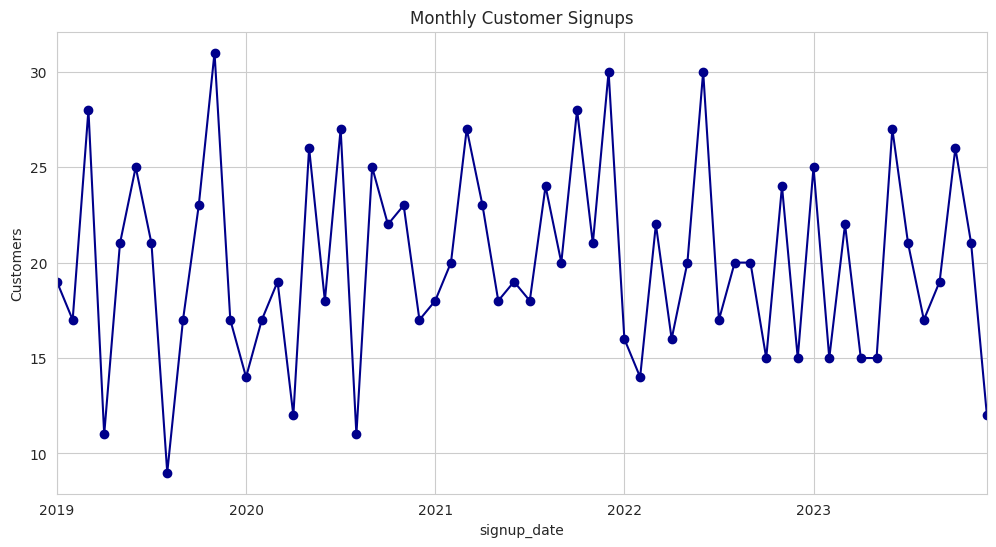

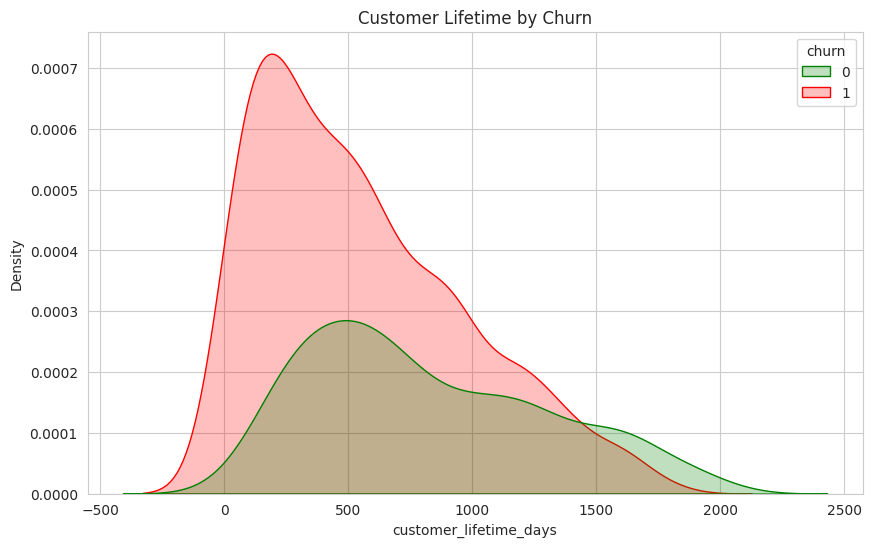

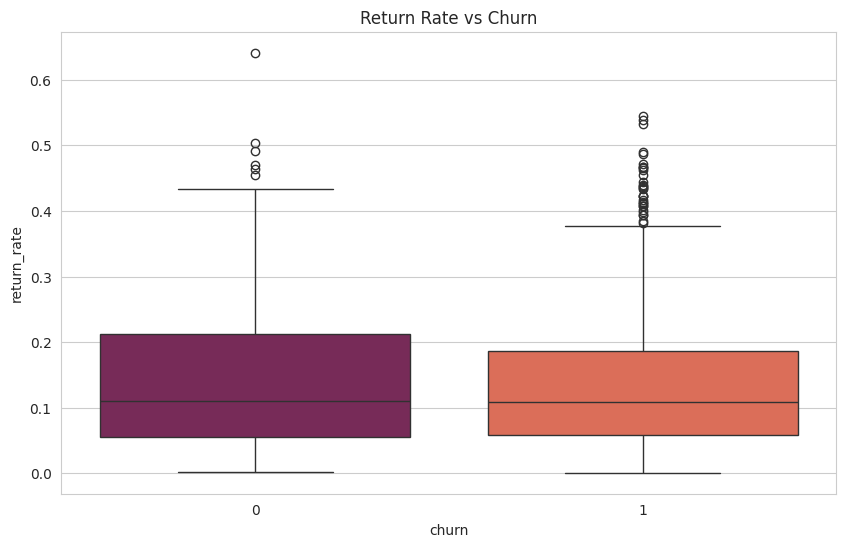

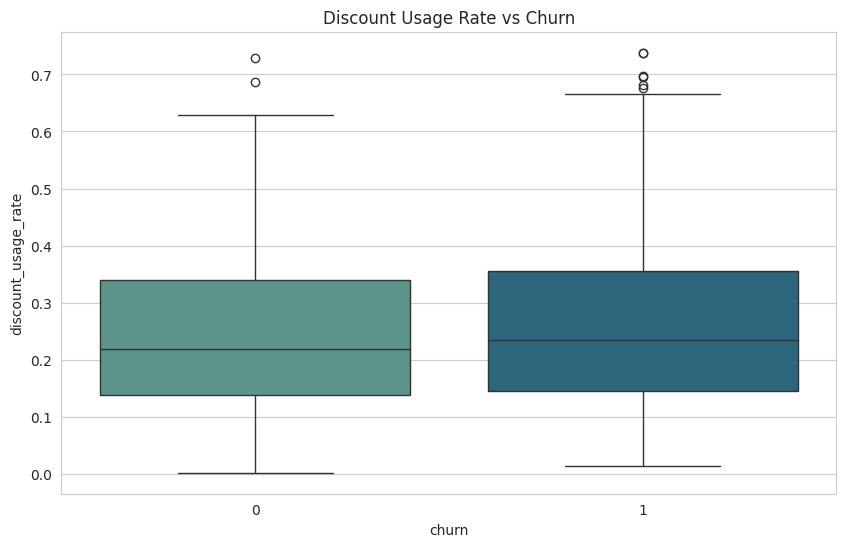

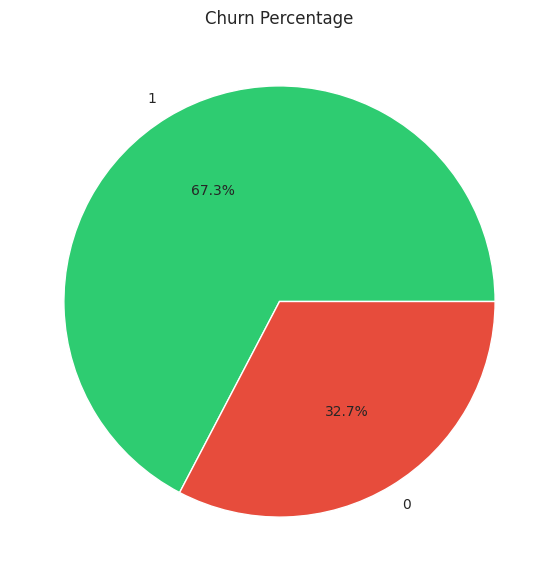

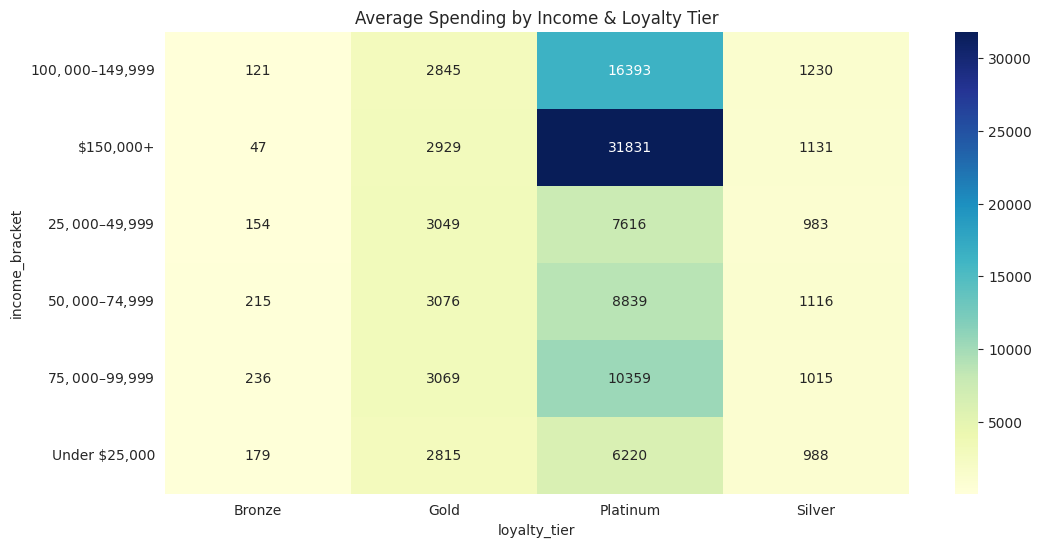

EDA Visualization Completed Successfully


In [14]:
# ----------------------------------------------------------
# Date Conversion
# ----------------------------------------------------------
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# ----------------------------------------------------------
# Styling
# ----------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ==========================================================
# 1. TARGET VARIABLE ANALYSIS
# ==========================================================

plt.figure(figsize=(8,5))
sns.countplot(
    x='churn',
    data=df,
    palette=['#2ECC71','#E74C3C']
)
plt.title("Customer Churn Distribution", fontsize=16)
plt.show()

# ==========================================================
# 2. NUMERICAL FEATURES DISTRIBUTION
# ==========================================================

numerical_cols = [
    'age',
    'customer_lifetime_days',
    'days_since_last_purchase',
    'total_orders',
    'total_spent_usd',
    'avg_order_value_usd',
    'discount_usage_rate',
    'return_rate',
    'avg_session_duration_min',
    'avg_pages_per_session',
    'satisfaction_score'
]

colors = [
    'skyblue',
    'orange',
    'green',
    'red',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan',
    'gold'
]

for col, color in zip(numerical_cols, colors):

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        color=color
    )

    plt.title(f'Distribution of {col}')
    plt.show()

# ==========================================================
# 3. BOXPLOTS FOR OUTLIER DETECTION
# ==========================================================

for col, color in zip(numerical_cols, colors):

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=color
    )

    plt.title(f'Boxplot of {col}')
    plt.show()

# ==========================================================
# 4. CATEGORICAL FEATURE ANALYSIS
# ==========================================================

categorical_cols = [
    'gender',
    'country',
    'region',
    'income_bracket',
    'preferred_category',
    'preferred_payment_method',
    'device_type',
    'loyalty_tier',
    'newsletter_subscribed',
    'referral_source'
]

for col in categorical_cols:

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df,
        x=col,
        palette='Set2'
    )

    plt.xticks(rotation=45)
    plt.title(f'Count Plot - {col}')

    plt.show()

# ==========================================================
# 5. CORRELATION HEATMAP
# ==========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# 6. CHURN VS NUMERICAL FEATURES
# ==========================================================

for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x='churn',
        y=col,
        data=df,
        palette=['#1ABC9C','#E74C3C']
    )

    plt.title(f'{col} vs Churn')
    plt.show()

# ==========================================================
# 7. CHURN VS CATEGORICAL FEATURES
# ==========================================================

for col in categorical_cols:

    plt.figure(figsize=(12,5))

    sns.countplot(
        x=col,
        hue='churn',
        data=df,
        palette='viridis'
    )

    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')

    plt.show()

# ==========================================================
# 8. CUSTOMER AGE ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    x='churn',
    y='age',
    data=df,
    palette=['#3498DB','#E74C3C']
)

plt.title("Age Distribution by Churn")
plt.show()

# ==========================================================
# 9. TOTAL SPENT ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='total_orders',
    y='total_spent_usd',
    hue='churn',
    palette='Set1',
    s=100
)

plt.title("Total Orders vs Total Spent")
plt.show()

# ==========================================================
# 10. SATISFACTION SCORE ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='churn',
    y='satisfaction_score',
    palette=['green','red']
)

plt.title("Average Satisfaction Score by Churn")
plt.show()

# ==========================================================
# 11. LOYALTY TIER ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='loyalty_tier',
    hue='churn',
    palette='Spectral'
)

plt.title("Loyalty Tier vs Churn")
plt.show()

# ==========================================================
# 12. INCOME BRACKET ANALYSIS
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='income_bracket',
    hue='churn',
    palette='cool'
)

plt.title("Income Bracket vs Churn")
plt.xticks(rotation=45)

plt.show()

# ==========================================================
# 13. DEVICE TYPE ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='device_type',
    hue='churn',
    palette='magma'
)

plt.title("Device Type vs Churn")

plt.show()

# ==========================================================
# 14. PAIRPLOT
# ==========================================================

selected_cols = [
    'age',
    'total_orders',
    'total_spent_usd',
    'avg_order_value_usd',
    'satisfaction_score',
    'churn'
]

sns.pairplot(
    df[selected_cols],
    hue='churn',
    palette='husl'
)

plt.show()

# ==========================================================
# 15. MONTHLY CUSTOMER SIGNUPS
# ==========================================================

monthly_signup = (
    df.set_index('signup_date')
      .resample('M')
      .size()
)

plt.figure(figsize=(12,6))

monthly_signup.plot(
    color='darkblue',
    marker='o'
)

plt.title("Monthly Customer Signups")
plt.ylabel("Customers")
plt.show()

# ==========================================================
# 16. CUSTOMER LIFETIME ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='customer_lifetime_days',
    hue='churn',
    fill=True,
    palette=['green','red']
)

plt.title("Customer Lifetime by Churn")
plt.show()

# ==========================================================
# 17. RETURN RATE ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='churn',
    y='return_rate',
    palette='rocket'
)

plt.title("Return Rate vs Churn")
plt.show()

# ==========================================================
# 18. DISCOUNT USAGE ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='churn',
    y='discount_usage_rate',
    palette='crest'
)

plt.title("Discount Usage Rate vs Churn")
plt.show()

# ==========================================================
# 19. CHURN PERCENTAGE
# ==========================================================

churn_pct = (
    df['churn']
    .value_counts(normalize=True)
    *100
)

plt.figure(figsize=(7,7))

plt.pie(
    churn_pct,
    labels=churn_pct.index,
    autopct='%1.1f%%',
    colors=['#2ECC71','#E74C3C']
)

plt.title("Churn Percentage")
plt.show()

# ==========================================================
# 20. CUSTOMER SEGMENT HEATMAP
# ==========================================================

pivot = pd.pivot_table(
    df,
    values='total_spent_usd',
    index='income_bracket',
    columns='loyalty_tier',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu',
    fmt='.0f'
)

plt.title("Average Spending by Income & Loyalty Tier")
plt.show()

print("EDA Visualization Completed Successfully")

## Feature engineering

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.model_selection import cross_val_score

In [16]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month

df['purchase_year'] = df['last_purchase_date'].dt.year
df['purchase_month'] = df['last_purchase_date'].dt.month

df.drop(
    ['signup_date','last_purchase_date'],
    axis=1,
    inplace=True
)

In [17]:
TARGET = "churn"

In [18]:
df.drop("customer_id", axis=1, inplace=True)

In [19]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(960, 25)
(240, 25)


In [21]:
categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print(categorical_features)
print(numerical_features)

['gender', 'country', 'region', 'income_bracket', 'preferred_category', 'preferred_payment_method', 'device_type', 'loyalty_tier', 'referral_source']
['age', 'customer_lifetime_days', 'days_since_last_purchase', 'total_orders', 'total_spent_usd', 'avg_order_value_usd', 'discount_usage_rate', 'return_rate', 'newsletter_subscribed', 'avg_session_duration_min', 'avg_pages_per_session', 'satisfaction_score', 'signup_year', 'signup_month', 'purchase_year', 'purchase_month']


In [22]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "AdaBoost":
        AdaBoostClassifier(),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(
            probability=True
        )
}

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        78
           1       0.99      0.98      0.99       162

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240



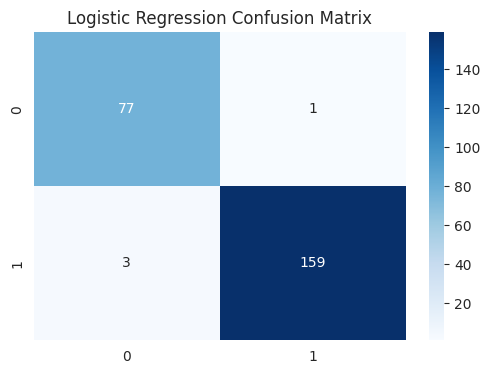

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       162

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



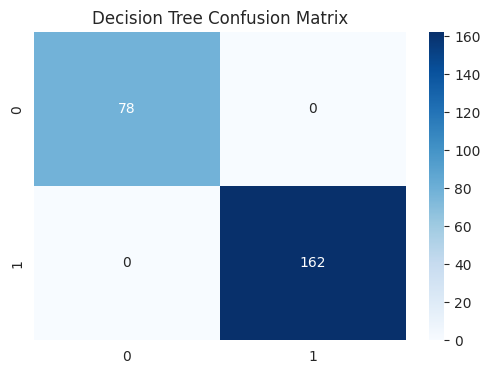

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        78
           1       0.99      0.98      0.99       162

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240



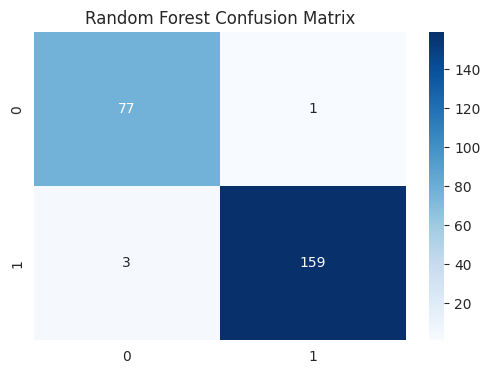

Extra Trees
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        78
           1       0.99      0.98      0.99       162

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240



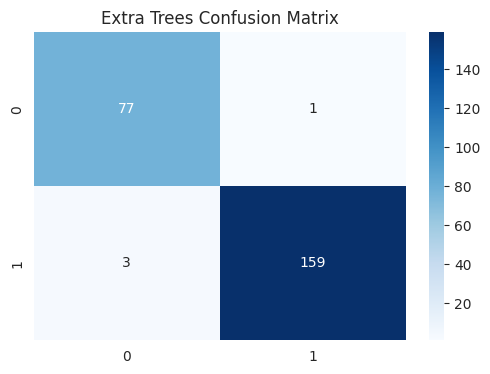

Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       162

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



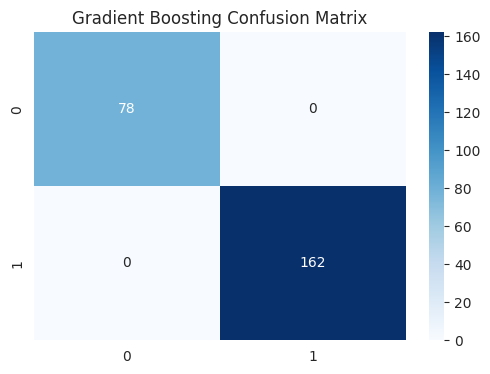

AdaBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       162

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



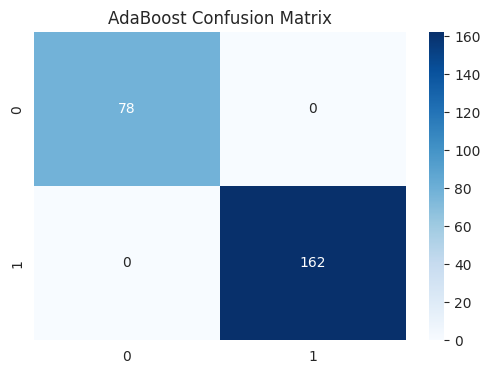

KNN
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        78
           1       0.91      0.91      0.91       162

    accuracy                           0.88       240
   macro avg       0.86      0.86      0.86       240
weighted avg       0.88      0.88      0.88       240



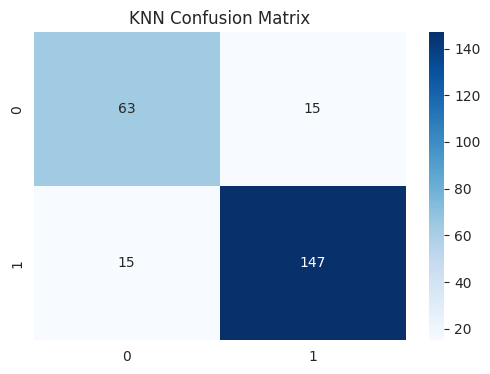

SVM
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        78
           1       0.99      0.96      0.98       162

    accuracy                           0.97       240
   macro avg       0.96      0.98      0.97       240
weighted avg       0.97      0.97      0.97       240



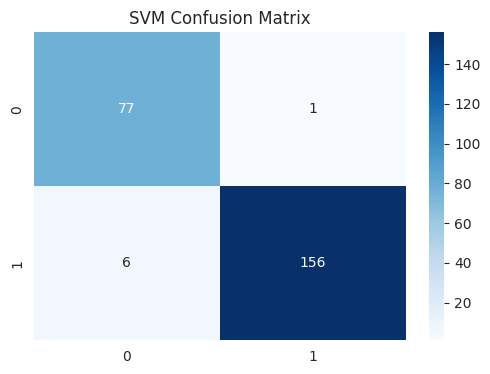

In [24]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    prob = pipe.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    roc_auc = roc_auc_score(y_test, prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("="*60)
    print(name)
    print("="*60)

    print(classification_report(
        y_test,
        pred
    ))

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [25]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
1        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000
4    Gradient Boosting  1.000000   1.000000  1.000000  1.000000  1.000000
5             AdaBoost  1.000000   1.000000  1.000000  1.000000  1.000000
2        Random Forest  0.983333   0.993750  0.981481  0.987578  0.999367
3          Extra Trees  0.983333   0.993750  0.981481  0.987578  0.999288
0  Logistic Regression  0.983333   0.993750  0.981481  0.987578  0.998734
7                  SVM  0.970833   0.993631  0.962963  0.978056  0.996676
6                  KNN  0.875000   0.907407  0.907407  0.907407  0.931228


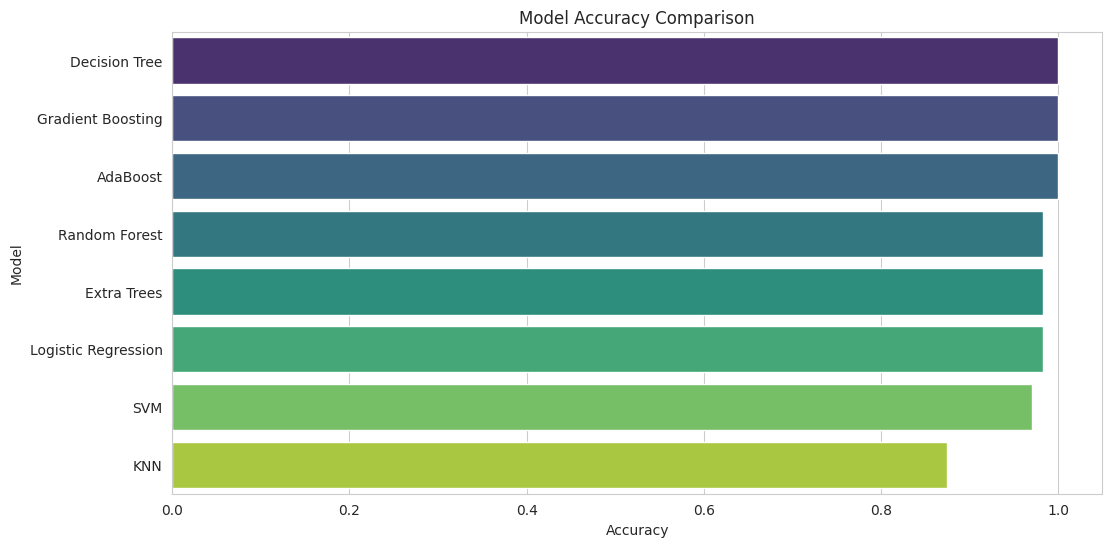

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.show()

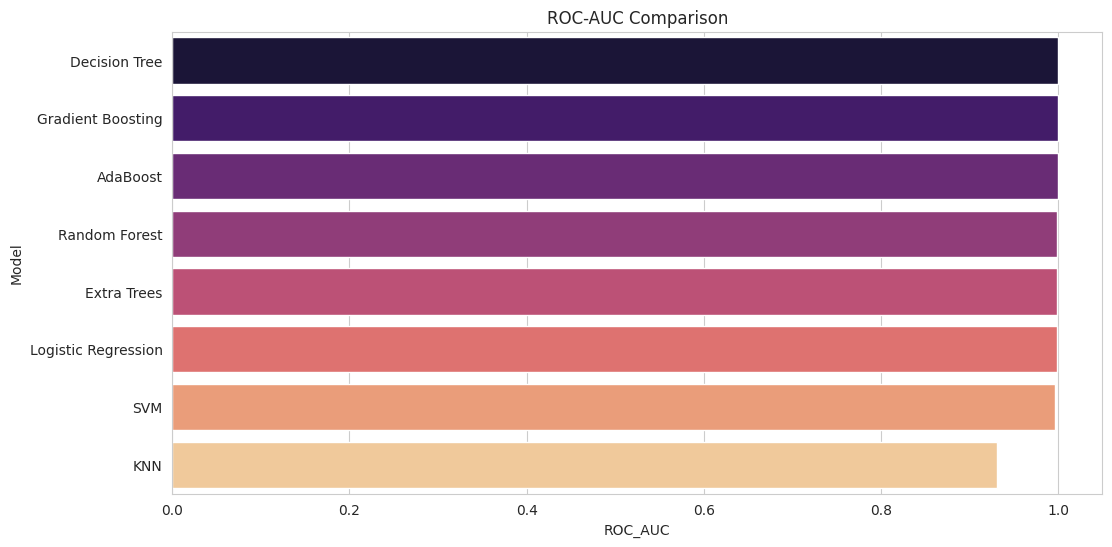

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="ROC_AUC",
    y="Model",
    palette="magma"
)

plt.title("ROC-AUC Comparison")
plt.show()

<Figure size 1000x800 with 0 Axes>

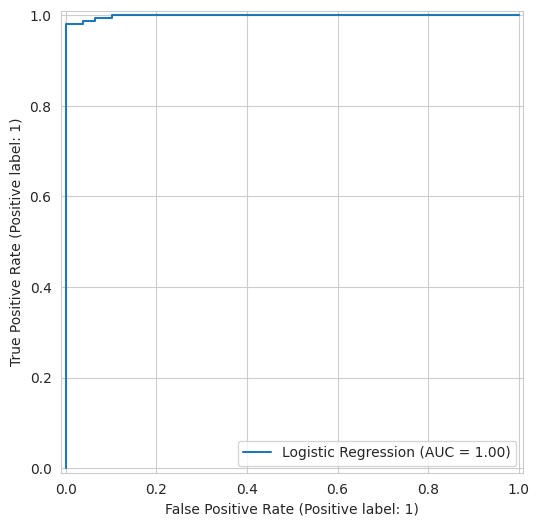

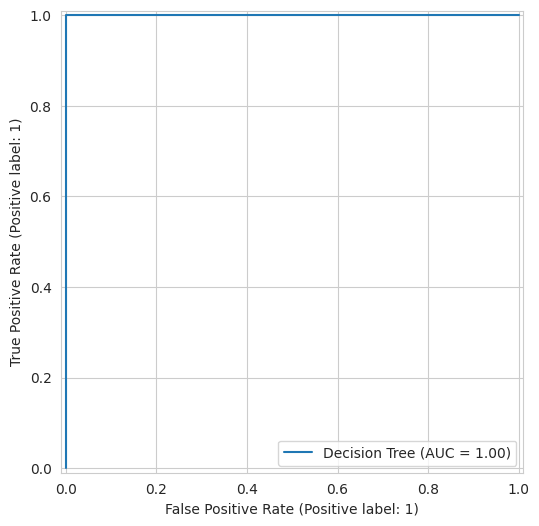

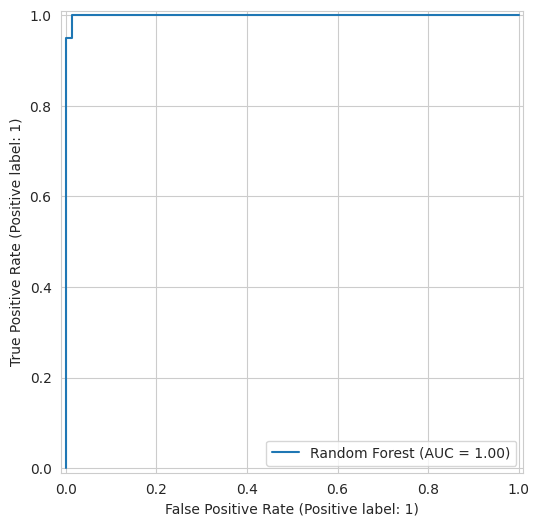

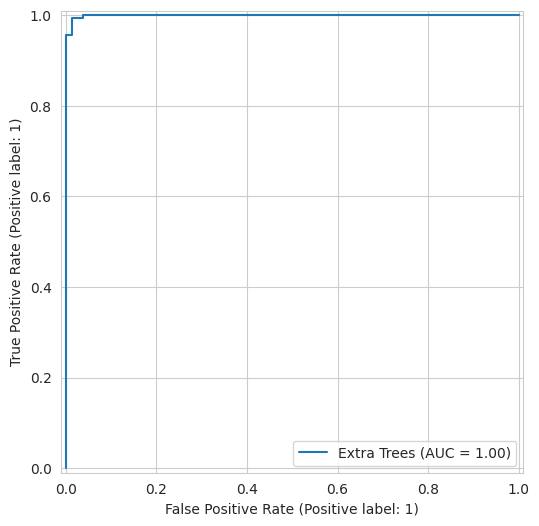

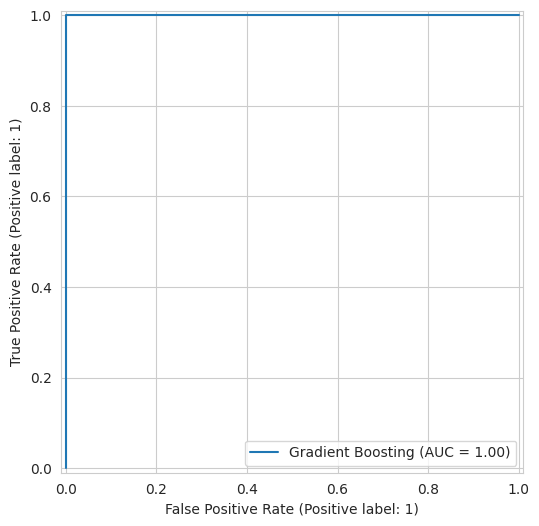

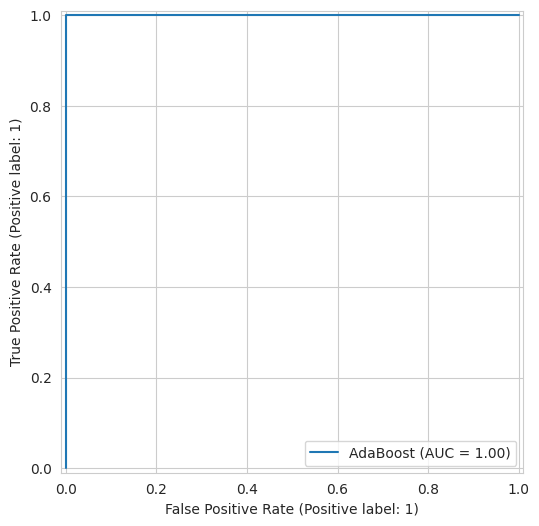

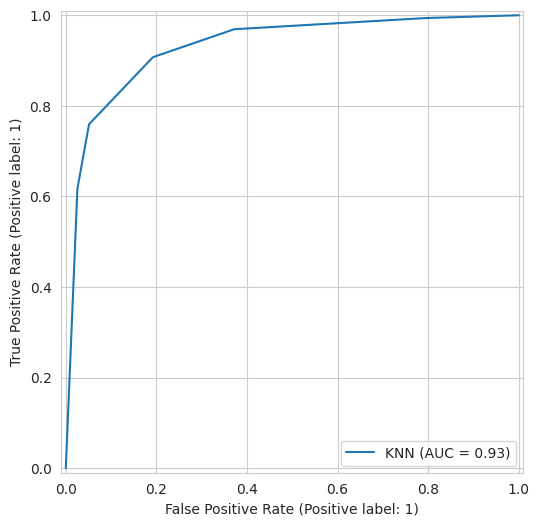

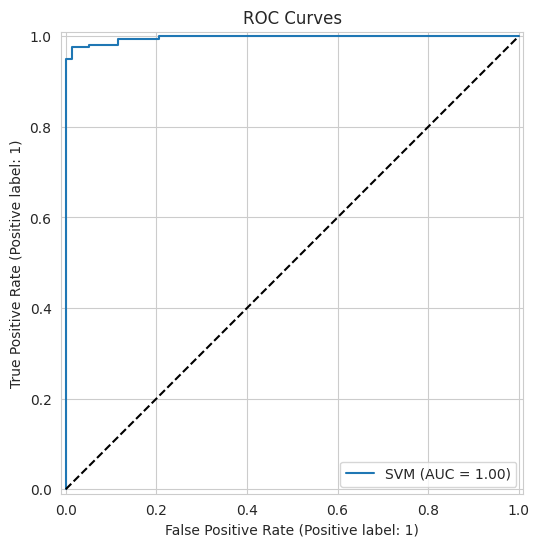

In [28]:
plt.figure(figsize=(10,8))

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        pipe,
        X_test,
        y_test,
        name=name
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.title("ROC Curves")
plt.show()

In [29]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     RandomForestClassifier(
         n_estimators=300,
         random_state=42
     ))
])

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("CV ROC-AUC Scores:")
print(scores)

print("\nMean ROC-AUC:")
print(scores.mean())

CV ROC-AUC Scores:
[1.         1.         0.99976258 0.99964387 1.        ]

Mean ROC-AUC:
0.9998812915479582


                                            Feature  Importance
2                     num__days_since_last_purchase    0.349987
14                               num__purchase_year    0.318933
11                          num__satisfaction_score    0.056620
12                                 num__signup_year    0.045684
1                       num__customer_lifetime_days    0.035023
3                                 num__total_orders    0.020702
4                              num__total_spent_usd    0.016363
7                                  num__return_rate    0.011235
5                          num__avg_order_value_usd    0.011050
15                              num__purchase_month    0.011041
6                          num__discount_usage_rate    0.010974
10                       num__avg_pages_per_session    0.009916
13                                num__signup_month    0.009788
0                                          num__age    0.008573
9                     num__avg_session_d

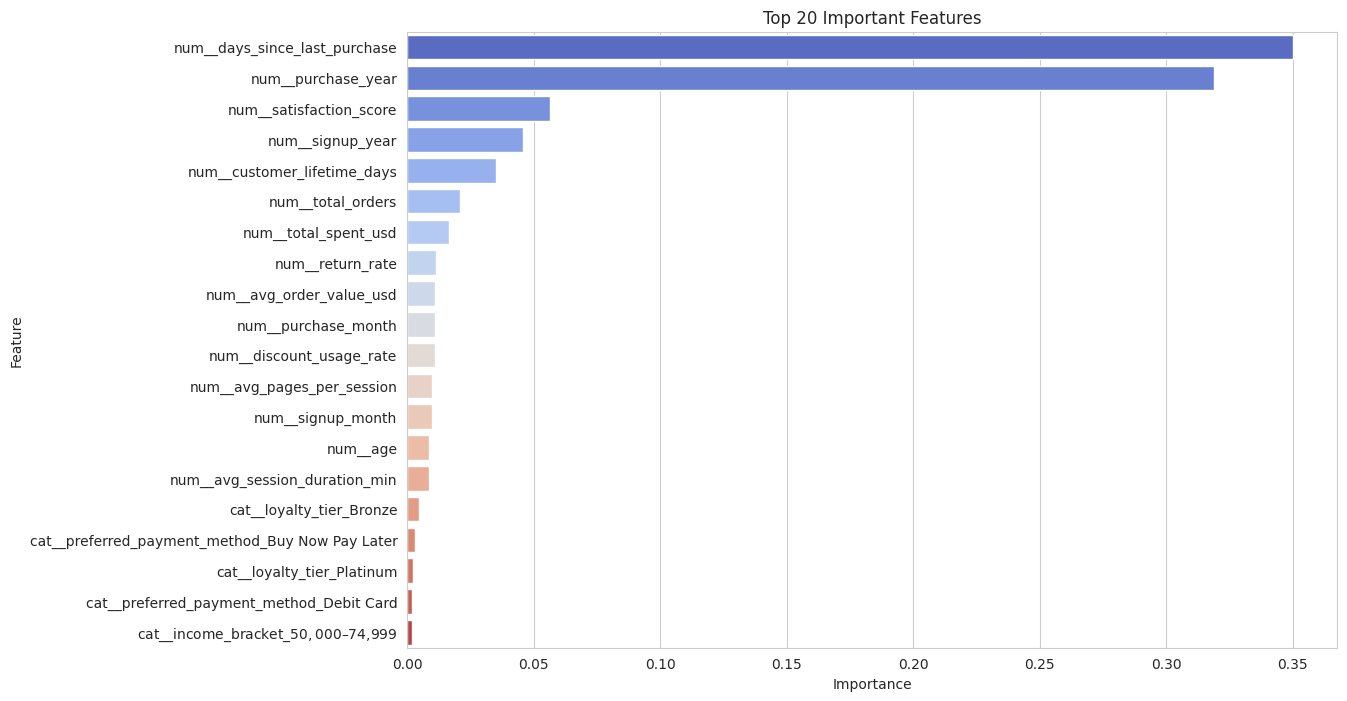

In [30]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     RandomForestClassifier(
         n_estimators=300,
         random_state=42
     ))
])

rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = rf_pipe.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(
    importance_df.head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature",
    palette="coolwarm"
)

plt.title("Top 20 Important Features")
plt.show()

In [31]:
best_row = results_df.iloc[0]

print("Best Model")
print(best_row)

Best Model
Model        Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1                     1.0
ROC_AUC                1.0
Name: 1, dtype: object


## Thank you....pls upvote!!!!!!!!!!!!!!!!!!!!!